In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2

# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *
from src.nominal_speed_func import *

### データの読み込みとフィルタリング

In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

%load_ext autoreload
%autoreload 2
    
# 現在のフォルダの「1つ上の階層（../）」をシステムのパスに追加する
sys.path.append(os.path.abspath(".."))

#作成したモジュールをインポート
from src.data_prep import *

# データの読み込みと前処理
df = load_trajectory_data()

#　フリッカリングノイズを除去
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=50)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=50) 

# ① ペアID付与
df_with_pairs = give_pair_id(df_clean)

# ② モードID付与
df_with_mode = give_mode_id_with_pair_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane_with_pair_id(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode_with_pair_id(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration_with_pair_id(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff_with_pair_id(df_duration)

# ⑦ 加速度フィルタ
df_final = filter_acceleration_with_pair_id(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type_with_pair_id(df_final)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(4566387, 19)
フリッカリング除去完了
補正されたブロック数: 1,395
行数: 4,566,387
フリッカリング除去完了
補正されたブロック数: 243
行数: 4,566,387
モードID別ペア数:
mode_id
1.0    11758
2.0      416
3.0      531
4.0       40
5.0      384
dtype: int64
フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,361,142
除外された行数: 205,245

ペア数: 13,129
フィルタ前: 4,361,142行
フィルタ後: 2,338,121行
除外された行数: 2,023,021行

車線の分布:
Lane_ID
2.0    799894
3.0    689226
4.0    849001
Name: count, dtype: int64
フィルタ前のペア数: 5,443
フィルタ後のペア数: 5,375
除外されたペア数: 68

モードID別ペア数:
mode_id
1.0    4800
2.0     227
3.0     314
4.0      34
dtype: int64
フィルタ前のペア数: 5,375
フィルタ後のペア数: 1,577
除外されたペア数: 3,798

フィルタ前の行数: 2,335,579
フィルタ後の行数: 1,508,130
カットオフ前の行数: 1,508,130
カットオフ後の行数: 1,192,730
除外された行数: 315,400

カットオフ前のペア数: 1,577
カットオフ後のペア数: 1,577
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,192,730
フィルタ後の行数: 895,533
除外された行数: 297,197

フィルタ前のペア数: 1,577
フィルタ後のペア数: 1,577

===最終結果===
行数: 895,533
ペア数: 1,577
追従ペア数:
pair_type
C-C    1456
C-T  

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Preceding,Following,Space_Headway,Time_Headway,time_period,pair_id,leader_class,ego_class,mode_id,pair_type
100,11,157,864,1113433150600,15.236,130.989,6042830.240,2133199.574,17.3,8.4,...,1.0,0,43.76,5.83,1,13.0,2.0,2,1.0,C-C
101,11,158,864,1113433150700,15.212,131.739,6042830.123,2133200.315,17.3,8.4,...,1.0,0,44.06,5.87,1,13.0,2.0,2,1.0,C-C
102,11,159,864,1113433150800,15.188,132.489,6042830.006,2133201.056,17.3,8.4,...,1.0,0,44.36,5.91,1,13.0,2.0,2,1.0,C-C
103,11,160,864,1113433150900,15.163,133.239,6042829.889,2133201.797,17.3,8.4,...,1.0,0,44.66,5.95,1,13.0,2.0,2,1.0,C-C
104,11,161,864,1113433151000,15.139,133.990,6042829.772,2133202.539,17.3,8.4,...,1.0,0,44.96,5.99,1,13.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508023,3006,2950,828,1113437859900,42.358,1389.949,6042683.839,2134451.291,15.8,6.9,...,479.0,491,31.61,2.64,3,19256.0,2.0,2,1.0,C-C
1508024,3006,2951,828,1113437860000,42.352,1391.149,6042683.641,2134452.475,15.8,6.9,...,479.0,491,31.91,2.66,3,19256.0,2.0,2,1.0,C-C
1508025,3006,2952,828,1113437860100,42.345,1392.350,6042683.443,2134453.658,15.8,6.9,...,479.0,491,32.19,2.69,3,19256.0,2.0,2,1.0,C-C
1508026,3006,2953,828,1113437860200,42.340,1393.544,6042683.246,2134454.842,15.8,6.9,...,479.0,491,32.49,2.71,3,19256.0,2.0,2,1.0,C-C


### 異常な密度を検知して除外<br>
名目速度関数の推定では異常な密度をもつデータは除外する。<br>
マクロ密度を考える際には問題はないため、それ以降は推定時では除外したデータも推定された名目速度関数に従うと仮定して進める。<br>

車体が少なくとも4mあるとして、15feet=約4.5m　だから、お尻と頭の距離が0.5m以下のデータが3600件強ある。<br>



In [3]:
#密度を確認
FT_TO_M = 0.3048 #フィートにこれをかけたらメートルになる。　


# まず異常値の実態を確認 15feet=4.572mくらい
print("Space_Headway <= 0feet の行数:", (df_final['Space_Headway'] <= 0).sum())
print("Space_Headway <= 14feeet の行数:", (df_final['Space_Headway'] <= 14).sum())
print("Space_Headway <= 15feeet の行数:", (df_final['Space_Headway'] <= 15).sum())
print("Space_Headway(feet)の分布:")
print(df_final['Space_Headway'].describe())
print("\n下位1%の値:", df_final['Space_Headway'].quantile(0.01), "feet")

Space_Headway <= 0feet の行数: 0
Space_Headway <= 14feeet の行数: 2753
Space_Headway <= 15feeet の行数: 3689
Space_Headway(feet)の分布:
count    895533.000000
mean         44.226897
std          19.817101
min           0.010000
25%          30.320000
50%          39.820000
75%          52.880000
max         250.990000
Name: Space_Headway, dtype: float64

下位1%の値: 17.3 feet


#### ノイズがありそうだから平滑化してみる

In [4]:
import numpy as np
import math

#窓幅は奇数でなければならない
def savgol_filter_numpy(y, window_length, polyorder, deriv=0, delta=1.0):
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n < window_length: #データ点がウィンドウ長より少ない場合は、元のデータを返す
        return y.copy()

    half_window = (window_length - 1) // 2 #窓は奇数だから
    x = np.arange(-half_window, half_window + 1)
    A = np.vander(x, polyorder + 1, increasing=True)
    coeffs = np.linalg.pinv(A)[deriv] * (math.factorial(deriv) / (delta ** deriv))

    smoothed_interior = np.convolve(y, coeffs[::-1], mode='valid')

    result = y.copy()
    result[half_window: n - half_window] = smoothed_interior
    return result

def smooth_spacing(df, window_length=11, polyorder=3, spacing_col='Space_Headway', max_gap_frames=1):
    """
    車間距離(Space_Headway)を、追従ペア(temp_pair_id)ごとに独立して
    Savitzky-Golayフィルタで平滑化する。
    同一車両でも、別々の追従区間をまたいで平滑化しないよう、
    Vehicle_ID/time_periodではなくtemp_pair_idでグループ化する。
    """
    df_paired = make_temp_pair_id(df, max_gap_frames=max_gap_frames)

    def _smooth(s):
        return pd.Series(
            savgol_filter_numpy(s.values, window_length=window_length, polyorder=polyorder),
            index=s.index
        )

    df_paired[f'{spacing_col}_smooth'] = (
        df_paired.dropna(subset=['temp_pair_id'])
        .groupby('temp_pair_id')[spacing_col]
        .transform(_smooth)
    )

    return df_paired.drop(columns='temp_pair_id')



In [5]:
df_fina_smooth = smooth_spacing(df_final, window_length=100, polyorder=3)

sample_row = df_final.iloc[20444]
sample_id = sample_row['Vehicle_ID']
sample_tp = sample_row['time_period']
print(f"描画対象の Vehicle_ID: {sample_id}, time_period: {sample_tp}")

plot_space_headway_time_series(df_final, vehicle_id=sample_id, time_period=sample_tp, space_headway_col='Space_Headway_smooth')

描画対象の Vehicle_ID: 1317.0, time_period: 1.0


KeyError: 'Space_Headway_smooth'

描画対象の Vehicle_ID: 2994.0, time_period: 1.0


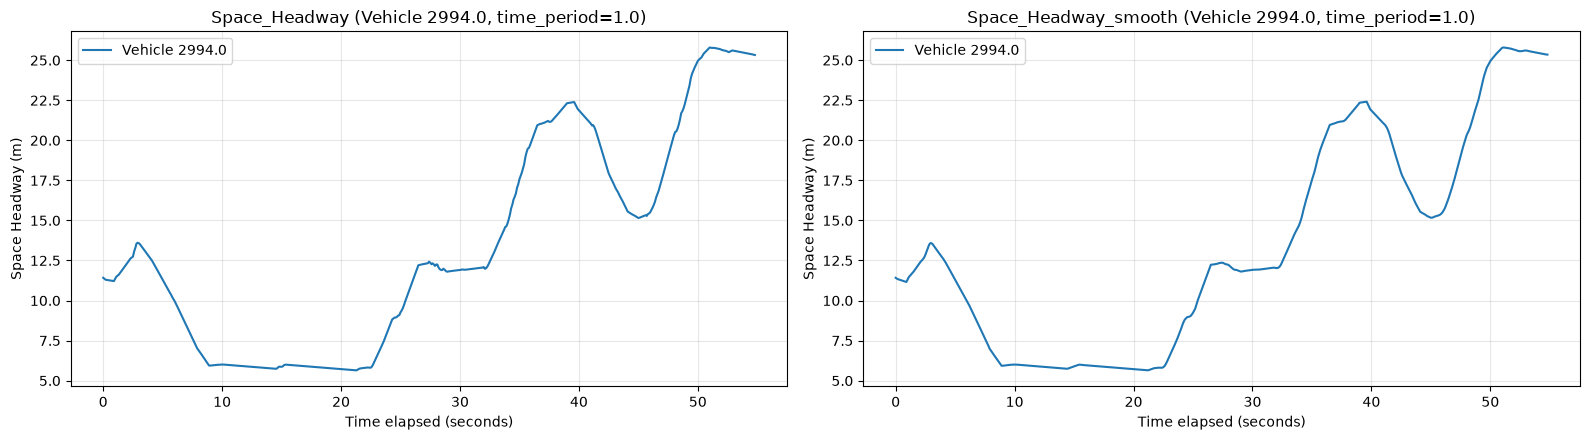

In [8]:
def plot_space_headway_time_series(df, vehicle_id, time_period=None, time_col='relative_sec',
                                     use_meters=True, space_headway_col='Space_Headway', ax=None):
    mask = df['Vehicle_ID'] == vehicle_id
    if time_period is not None:
        mask &= df['time_period'] == time_period

    sub = df[mask].copy().sort_values('Frame_ID')

    if sub.empty:
        print(f"エラー: Vehicle_ID {vehicle_id} (time_period={time_period}) のデータが見つかりません。")
        return

    if time_period is None and sub['time_period'].nunique() > 1:
        print(f"警告: Vehicle_ID {vehicle_id} は複数のtime_periodにまたがっています。")
        return

    FT_TO_M = 0.3048
    if use_meters:
        headway = sub[space_headway_col] * FT_TO_M
        unit_label = 'm'
    else:
        headway = sub[space_headway_col]
        unit_label = 'ft'

    if time_col == 'relative_sec':
        x_data = (sub['Frame_ID'] - sub['Frame_ID'].min()) * 0.1
        x_label = 'Time elapsed (seconds)'
    elif time_col == 'Frame_ID':
        x_data = sub['Frame_ID']
        x_label = 'Frame ID'
    else:
        x_data = sub[time_col]
        x_label = time_col

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 4.5))

    ax.plot(x_data, headway, color='tab:blue', linewidth=1.5, label=f'Vehicle {vehicle_id}')
    ax.set_title(f'{space_headway_col} (Vehicle {vehicle_id}, time_period={time_period})')
    ax.set_xlabel(x_label)
    ax.set_ylabel(f'Space Headway ({unit_label})')
    ax.grid(True, alpha=0.3)
    ax.legend()

    if standalone:
        plt.tight_layout()
        plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))


sample_row = df_final.iloc[115858]
sample_id = sample_row['Vehicle_ID']
sample_tp = sample_row['time_period']
print(f"描画対象の Vehicle_ID: {sample_id}, time_period: {sample_tp}")

plot_space_headway_time_series(df_final, vehicle_id=sample_id, time_period=sample_tp,
                                 space_headway_col='Space_Headway', ax=axes[0])
plot_space_headway_time_series(df_final, vehicle_id=sample_id, time_period=sample_tp,
                                 space_headway_col='Space_Headway_smooth', ax=axes[1])

plt.tight_layout()
plt.show()

In [6]:
#平滑化は時間でデータが途切れる前にやらないとおかしなこと(つながっていないデータを平滑化してしまう)になってしまう
df = load_trajectory_data()
df_clean_p = remove_flicker_noise(df, col='Preceding', threshold=50)
df_clean = remove_flicker_noise(df_clean_p, col='Lane_ID', threshold=50) 

#先に平滑化フィルタをかける
df_smooth = smooth_spacing(df_clean, window_length=11, polyorder=3, max_gap_frames=1)

# ① ペアID付与
df_with_pairs = give_pair_id(df_smooth)

# ② モードID付与
df_with_mode = give_mode_id_with_pair_id(df_with_pairs, df)

# ③ 追従していない行を除外 追従している車両のみのデータが完成
df_valid = filter_valid_pairs(df_with_mode)

# ④ 車線フィルタ（Lanes 2, 3, 4のみ）
df_lane = filter_lane_with_pair_id(df_valid)

# ⑤ モードフィルタ
df_mode = filter_mode_with_pair_id(df_lane)

# ⑥ 追従時間フィルタ
df_duration = filter_duration_with_pair_id(df_mode)

# ⑧ カットオフウィンドウ
df_cutoff = apply_cutoff_with_pair_id(df_duration)

# ⑦ 加速度フィルタ
df_final = filter_acceleration_with_pair_id(df_cutoff).copy()


# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")
assign_and_count_pair_type_with_pair_id(df_final)

(4566387, 19)
フリッカリング除去完了
補正されたブロック数: 1,395
行数: 4,566,387
フリッカリング除去完了
補正されたブロック数: 243
行数: 4,566,387
モードID別ペア数:
mode_id
1.0    11758
2.0      416
3.0      531
4.0       40
5.0      384
dtype: int64
フィルタ前の行数: 4,566,387
フィルタ後の行数: 4,361,142
除外された行数: 205,245

ペア数: 13,129
フィルタ前: 4,361,142行
フィルタ後: 2,338,121行
除外された行数: 2,023,021行

車線の分布:
Lane_ID
2.0    799894
3.0    689226
4.0    849001
Name: count, dtype: int64
フィルタ前のペア数: 5,443
フィルタ後のペア数: 5,375
除外されたペア数: 68

モードID別ペア数:
mode_id
1.0    4800
2.0     227
3.0     314
4.0      34
dtype: int64
フィルタ前のペア数: 5,375
フィルタ後のペア数: 1,577
除外されたペア数: 3,798

フィルタ前の行数: 2,335,579
フィルタ後の行数: 1,508,130
カットオフ前の行数: 1,508,130
カットオフ後の行数: 1,192,730
除外された行数: 315,400

カットオフ前のペア数: 1,577
カットオフ後のペア数: 1,577
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,192,730
フィルタ後の行数: 895,533
除外された行数: 297,197

フィルタ前のペア数: 1,577
フィルタ後のペア数: 1,577

===最終結果===
行数: 895,533
ペア数: 1,577
追従ペア数:
pair_type
C-C    1456
C-T      67
C-M       0
T-T       6
T-C      48
T-M       0
M-M       0
M-C       0
M-T      

,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,...,Following,Space_Headway,Time_Headway,time_period,Space_Headway_smooth,pair_id,leader_class,ego_class,mode_id,pair_type
100,11,157,864,1113433150600,15.236,130.989,6042830.240,2133199.574,17.3,8.4,...,0,43.76,5.83,1,43.757483,13.0,2.0,2,1.0,C-C
101,11,158,864,1113433150700,15.212,131.739,6042830.123,2133200.315,17.3,8.4,...,0,44.06,5.87,1,44.060000,13.0,2.0,2,1.0,C-C
102,11,159,864,1113433150800,15.188,132.489,6042830.006,2133201.056,17.3,8.4,...,0,44.36,5.91,1,44.361678,13.0,2.0,2,1.0,C-C
103,11,160,864,1113433150900,15.163,133.239,6042829.889,2133201.797,17.3,8.4,...,0,44.66,5.95,1,44.662098,13.0,2.0,2,1.0,C-C
104,11,161,864,1113433151000,15.139,133.990,6042829.772,2133202.539,17.3,8.4,...,0,44.96,5.99,1,44.956480,13.0,2.0,2,1.0,C-C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1508023,3006,2950,828,1113437859900,42.358,1389.949,6042683.839,2134451.291,15.8,6.9,...,491,31.61,2.64,3,31.541235,19256.0,2.0,2,1.0,C-C
1508024,3006,2951,828,1113437860000,42.352,1391.149,6042683.641,2134452.475,15.8,6.9,...,491,31.91,2.66,3,31.856270,19256.0,2.0,2,1.0,C-C
1508025,3006,2952,828,1113437860100,42.345,1392.350,6042683.443,2134453.658,15.8,6.9,...,491,32.19,2.69,3,32.179953,19256.0,2.0,2,1.0,C-C
1508026,3006,2953,828,1113437860200,42.340,1393.544,6042683.246,2134454.842,15.8,6.9,...,491,32.49,2.71,3,32.508998,19256.0,2.0,2,1.0,C-C


#### 平滑化を通してもおかしい値を除外 ミクロ密度の計算

In [26]:

def filter_invalid_headway(df, min_spacing_m=4.5, ft_to_m=0.3048):
    """
    Space_Headway(ft)に基づいて異常な小車間距離データをフィルタリングする関数
    """
    min_spacing_ft = min_spacing_m / ft_to_m
    df_filtered = df.copy()

    before = len(df_filtered)

    # フィルタリング条件: Space_Headway > min_spacing_ft の行だけを残す
    df_filtered = df_filtered[df_filtered['Space_Headway'] > min_spacing_ft]
    after = len(df_filtered)

    print(f"spacing <= {min_spacing_m}m ({min_spacing_ft:.2f}ft) の行を除外: {before:,} -> {after:,} (除外 {before-after:,}行)")
    
    return df_filtered


def compute_micro_density(df, ft_to_m=0.3048):
    """
    車間距離(ft)および速度(ft/s)からミクロ密度を算出する関数
    """
    df_computed = df.copy()

    # 1000m / (Space_Headway * ft_to_m)
    df_computed['mdensity_veh_km'] = 1000 / (df_computed['Space_Headway'] * ft_to_m)

    return df_computed


spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)


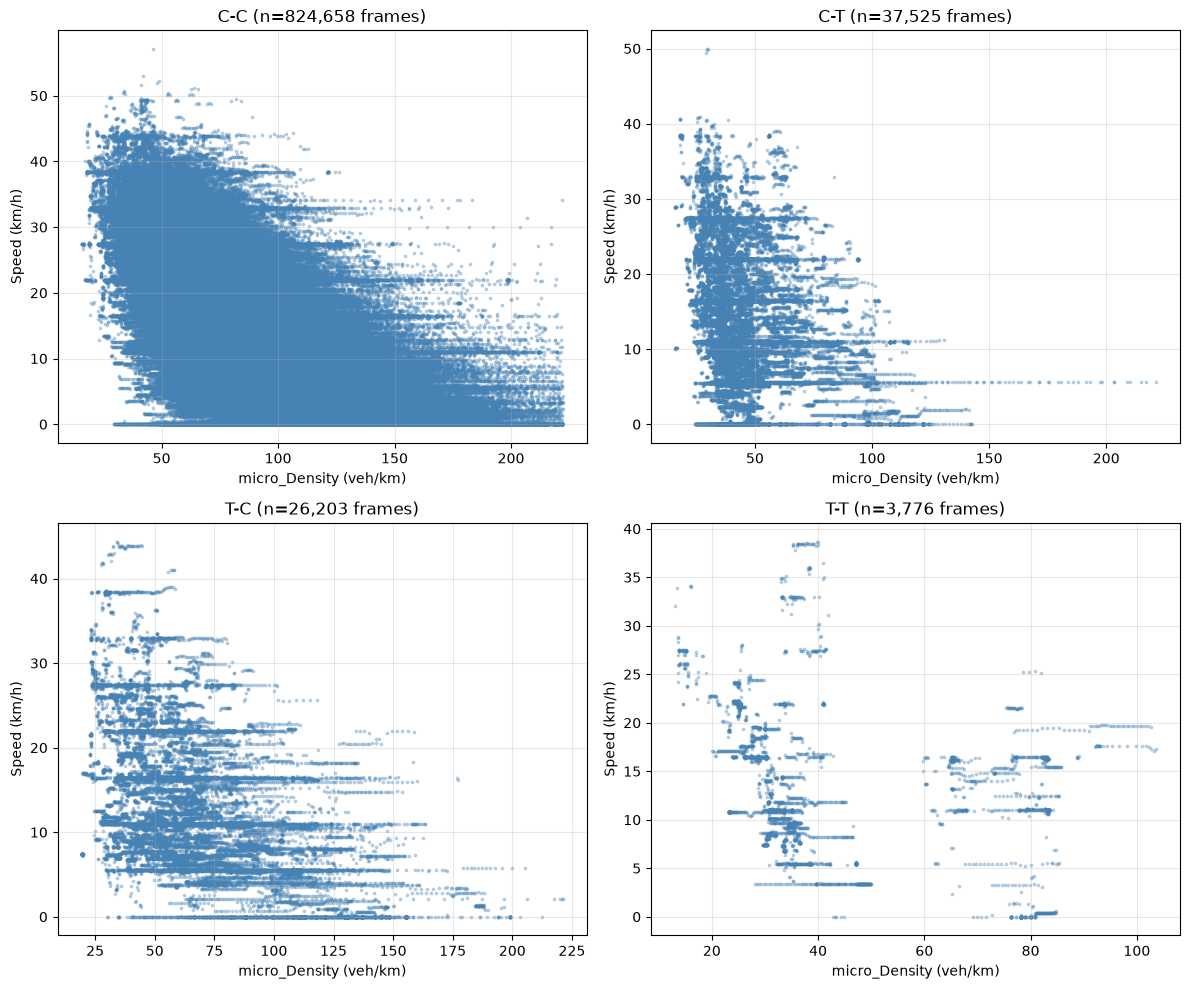

In [60]:
#レーン制限後のデータ
#  1. 異常データの除外処理
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)

# 2. 密度・速度・流量の計算
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

#除外後のペアタイプごとの密度速度分布を図示
pair_types = [1, 2, 3, 4]
mode_map = {
    1: 'C-C',
    2: 'C-T',
    3: 'T-C',
    4: 'T-T'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, pt in zip(axes.flat, pair_types):
    # df_fd から各モードのデータを抽出
    sub = df_fd[df_fd['mode_id'] == pt]
    
    # 計算済みの mdensity_veh_km を使用し、速度のみその場で換算してプロット
    speed_kmh = sub['v_Vel'] * FT_TO_M * 3.6
    
    ax.scatter(sub['mdensity_veh_km'], speed_kmh, s=3, alpha=0.3, color='steelblue')
    ax.set_xlabel('micro_Density (veh/km)')
    ax.set_ylabel('Speed (km/h)')
    ax.set_title(f'{mode_map[pt]} (n={len(sub):,} frames)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


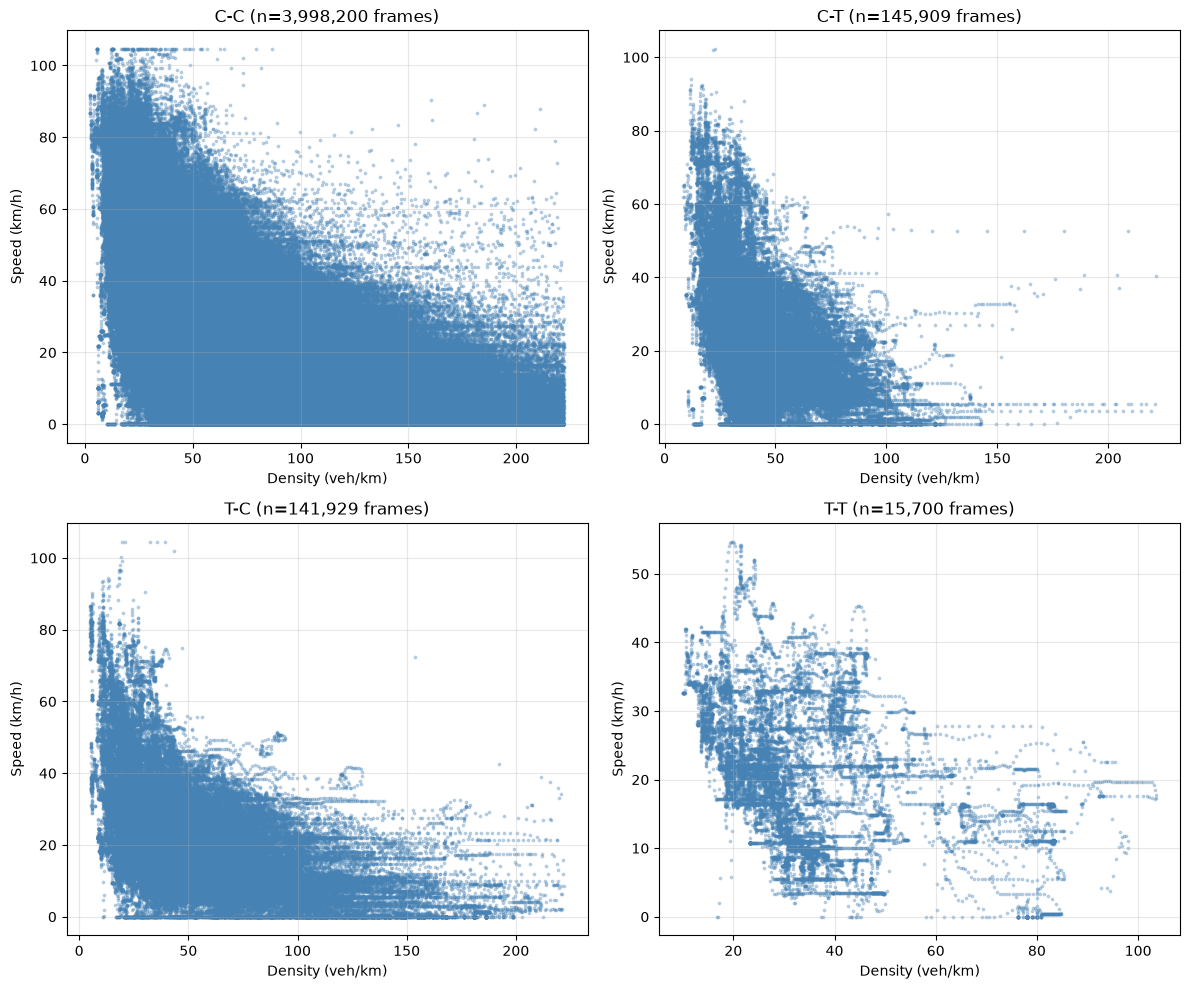

In [59]:
# 1. 異常データの除外処理
df_filtered = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)

# 2. 密度・速度・流量の計算
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)
#df_filtered = compute_micro_density(df_with_mode, ft_to_m=FT_TO_M)


#除外後のペアタイプごとの密度速度分布を図示
pair_types = [1, 2, 3, 4]
mode_map = {
    1: 'C-C',
    2: 'C-T',
    3: 'T-C',
    4: 'T-T'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, pt in zip(axes.flat, pair_types):
    sub = df_filtered[df_filtered['mode_id'] == pt]
    
    # プロット時に都度計算 (密度: veh/km, 速度: km/h)
    density_veh_km = 1000 / (sub['Space_Headway'] * FT_TO_M)
    speed_kmh = sub['v_Vel'] * FT_TO_M * 3.6
    
    ax.scatter(density_veh_km, speed_kmh, s=3, alpha=0.3, color='steelblue')
    ax.set_xlabel('Density (veh/km)')
    ax.set_ylabel('Speed (km/h)')
    ax.set_title(f'{mode_map[pt]} (n={len(sub):,} frames)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
print(df_fd.columns)

Index(['Vehicle_ID', 'Frame_ID', 'Total_Frames', 'Global_Time', 'Local_X',
       'Local_Y', 'Global_X', 'Global_Y', 'v_Length', 'v_Width', 'v_Class',
       'v_Vel', 'v_Acc', 'Lane_ID', 'Preceding', 'Following', 'Space_Headway',
       'Time_Headway', 'time_period', 'Space_Headway_smooth', 'pair_id',
       'leader_class', 'ego_class', 'mode_id', 'mdensity_veh_km'],
      dtype='str')


### 基本図を描くため、マクロ密度・平均速度の計算

In [ ]:
#　スナップショットからの密度、平均速度を計算する。
# 密度は車種ごとに計算。

def compute_macroscopic_snapshots(df, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5,
                                    L_m=None, n_lanes=None, frame_interval_ms=100):
    """
    Algorithm 1 Step 2: 一定間隔(デフォルト5フレーム=0.5秒)でスナップショットを取り、
    マクロ密度(veh/km/lane)・平均速度(km/h)・流率(veh/h/lane)を計算する。

    df: 車線・車種で絞り込む前の全車両trajectoryデータ(関数内でlanes/classesに絞る)
    lanes: 対象車線
    classes: 対象車種(2=car, 3=truck)
    snapshot_step_frames: 何フレームおきにスナップショットを取るか
    L_m: 区間長(m)1,640feet = 1,640 * 0.3048 = 499.872mメタデータではこう書いているが、実際のデータのy座標の範囲から自動計算する 見えない加工の可能性を避けるために（カメラの画角で切られている部分があるとか）
    n_lanes: 車線数。3
    """
    FT_TO_M = 0.3048
    step_ms = frame_interval_ms * snapshot_step_frames  # 500ms

    # time_periodごとに、スナップショットを撮る時刻の集合を作成 
    valid_times = set()
    for tp, group in df.groupby('time_period'):
        # 車種を絞り込む前の全データから最小値(t_min)・最大値(t_max)を取得
        t_min = int(group['Global_Time'].min())
        t_max = int(group['Global_Time'].max())
        
        # t_min始まりの0.5秒(500ms)ごとの時刻配列を作成し、集合に追加
        snapshot_times_tp = set(range(t_min, t_max + 1, step_ms))
        valid_times.update(snapshot_times_tp)

    # データを車線と車種で絞り込む
    target = df[df['Lane_ID'].isin(lanes) & df['v_Class'].isin(classes)].copy()

    #車線の長さ・車線数
    #メタデータは使わないい　論文でもメタデータとは異なる長さが使われていた。
    if L_m is None:
        L_m = (target['Local_Y'].max() - target['Local_Y'].min()) * FT_TO_M
    if n_lanes is None:
        n_lanes = len(lanes)
    L_km = L_m / 1000

    print(f"区間長: {L_m:.1f} m, 車線数: {n_lanes}")


    #絞り込み後のデータ(target)から、生成した0.5s刻みリスト(valid_times)に含まれる行だけを抽出←ちょっと冗長
    # snapshot_mask = target['Global_Time'].isin(valid_times)
    # snap_rows = target[snapshot_mask]

    # snapshot_mask という変数を作らず、直接1行でフィルタリング
    snap_rows = target[target['Global_Time'].isin(valid_times)]

    agg = snap_rows.groupby(['time_period', 'Global_Time', 'v_Class']).agg(
        n_vehicles=('Vehicle_ID', 'size'),#車種ごとの車両数
        speed_kmh=('v_Vel', lambda s: (s * FT_TO_M * 3.6).mean())#平均速度　feet/s -> m/s -> km/h
    ).reset_index()

    agg['density_veh_km'] = agg['n_vehicles'] / (L_km * n_lanes)#マクロ密度の計算
    agg['flow_veh_h'] = agg['density_veh_km'] * agg['speed_kmh']#流量の計算

    return agg

#マクロ密度は、ミクロ密度がおかしくても問題ないため除外前データを使う
df_macro_density = compute_macroscopic_snapshots(df, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)

df_macro_density.head()


区間長: 545.8 m, 車線数: 3


,time_period,Global_Time,v_Class,n_vehicles,speed_kmh,density_veh_km,flow_veh_h
0,1,1113433135300,3,1,12.157862,0.610694,7.424735
1,1,1113433135800,3,1,12.157862,0.610694,7.424735
2,1,1113433136300,2,1,13.716000,0.610694,8.376280
3,1,1113433136300,3,1,13.661136,0.610694,8.342775
4,1,1113433136800,2,1,13.737946,0.610694,8.389682


### 基本図を描く

区間長: 545.8 m, 車線数: 3


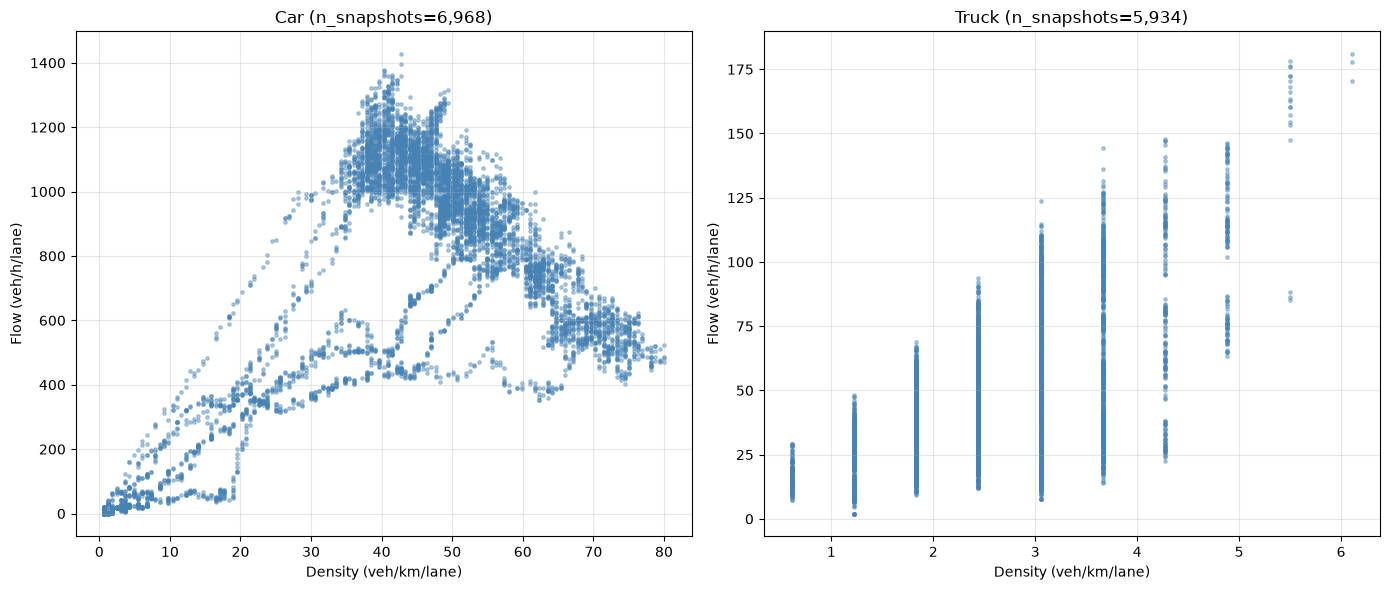

In [158]:
import matplotlib.pyplot as plt

#フィルタリング前データ
snapshots = compute_macroscopic_snapshots(df_clean, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)
#フィルタリング後データ
#snapshots = compute_macroscopic_snapshots(df_fd, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)

class_labels = {2: 'Car', 3: 'Truck'}
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cls in zip(axes, [2, 3]):
    sub = snapshots[snapshots['v_Class'] == cls]
    ax.scatter(sub['density_veh_km'], sub['flow_veh_h'], s=6, alpha=0.4, color='steelblue')
    ax.set_xlabel('Density (veh/km/lane)')
    ax.set_ylabel('Flow (veh/h/lane)')
    ax.set_title(f'{class_labels[cls]} (n_snapshots={len(sub):,})')
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

区間長: 545.8 m, 車線数: 3


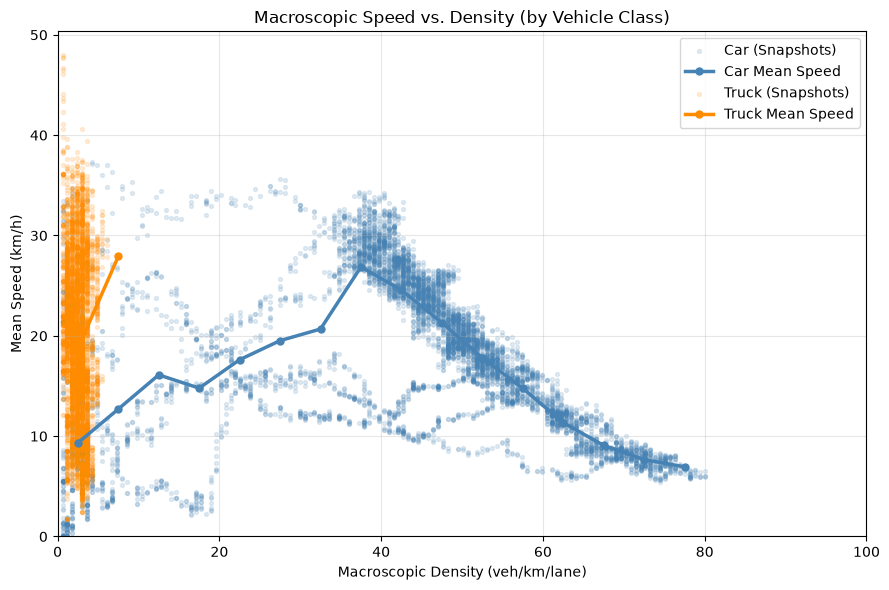

In [161]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_macroscopic_speed_density(
    df_macro,
    bin_width=5.0,
    max_density=100,
    min_samples=5,
    class_labels={2: 'Car', 3: 'Truck'},
    class_colors={2: 'steelblue', 3: 'darkorange'},
):
    """マクロ密度 (density_veh_km) と 平均速度 (speed_kmh)

    の関係を車種別にプロットする関数

    Parameters:
    -----------
    df_macro : pd.DataFrame
        compute_macroscopic_snapshots の返り値 (density_veh_km, speed_kmh,
        v_Class を含む)
    bin_width : float
        密度をグループ化するビン幅 (veh/km/lane)
    max_density : float
        X軸の最大表示範囲 (veh/km/lane)
    min_samples : int
        平均速度を計算する際に必要な最小スナップショット数 (ノイズ除去用)
    class_labels : dict
        v_Class のラベル表示名
    class_colors : dict
        v_Class ごとのプロット色
    """
    plt.figure(figsize=(9, 6))

    # 1. 密度ビンの設定 (0 ~ max_density)
    bins = np.arange(0, max_density + bin_width, bin_width)

    # 2. 車種ごとにプロット
    for v_cls in sorted(df_macro['v_Class'].unique()):
        label_name = class_labels.get(v_cls, f'v_Class={v_cls}')
        color_code = class_colors.get(v_cls, 'gray')

        # 対象車種に絞り込み
        sub = df_macro[df_macro['v_Class'] == v_cls].copy()
        if len(sub) == 0:
            continue

        # ① 生スナップショットデータの散布図（薄く背景に表示）
        plt.scatter(
            sub['density_veh_km'],
            sub['speed_kmh'],
            s=8,
            alpha=0.15,
            color=color_code,
            label=f'{label_name} (Snapshots)',
        )

        # ② 密度ビンの割り当てとビンごとの平均速度集計
        sub['density_bin'] = pd.cut(
            sub['density_veh_km'], bins=bins, include_lowest=True
        )

        bin_stats = sub.groupby('density_bin', observed=True).agg(
            mean_speed=('speed_kmh', 'mean'), count=('speed_kmh', 'count')
        )

        # サンプル数が少ない区間を除外
        valid_stats = bin_stats[bin_stats['count'] >= min_samples]
        bin_centers = [interval.mid for interval in valid_stats.index]

        # ③ ビンごとの平均速度プロット（太線 + マーカー）
        plt.plot(
            bin_centers,
            valid_stats['mean_speed'],
            marker='o',
            markersize=5,
            linewidth=2.5,
            color=color_code,
            label=f'{label_name} Mean Speed',
        )

    # 3. グラフ装飾
    plt.xlabel('Macroscopic Density (veh/km/lane)')
    plt.ylabel('Mean Speed (km/h)')
    plt.title('Macroscopic Speed vs. Density (by Vehicle Class)')
    plt.xlim(0, max_density)
    plt.ylim(bottom=0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

#マクロ密度は、ミクロ密度がおかしくても問題ないため除外前データを使う
df_macro_density = compute_macroscopic_snapshots(df_clean, lanes=(2, 3, 4), classes=(2, 3), snapshot_step_frames=5)

df_macro_density.head()

# --- 実行例 ---
plot_macroscopic_speed_density(
    df_macro_density, bin_width=5.0, max_density=100
)

### 1-a.名目速度関数の推定

#### 乗用車クラス　C-C追従

In [7]:
FT_TO_M = 0.3048

# 追従モードごとの全データにおける時間平均速度 (km/h) を計算
mode_avg_speed = df_final.groupby('mode_id')['v_Vel'].apply(
    lambda s: (s * FT_TO_M * 3.6).mean()
).reset_index(name='mean_speed_kmh')

# 結果の表示
print(mode_avg_speed)

   mode_id  mean_speed_kmh
0      1.0       13.299247
1      2.0       13.664426
2      3.0       12.391533
3      4.0       13.376343


In [8]:
import nlopt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error


def logistic_speed_density(rho, ub, uf, rhoc, theta1, theta2):
    """
    論文Eq(17)のロジスティック速度-密度モデル。
    f(rho) = ub + (uf - ub) / (1 + exp((rho-rhoc)/theta1))^theta2
    """
    exp_term = np.exp(np.clip((rho - rhoc) / theta1, -100, 100))  # オーバーフロー防止
    return ub + (uf - ub) / (1 + exp_term) ** theta2


def fit_nominal_speed_logistic(df, mode_id, density_col='mdensity_veh_km', speed_col='v_Vel',
                                 lower_bounds=None, upper_bounds=None, init_params=None,
                                 max_eval=15000, test_size=0.3, random_state=42):
    """
    論文Algorithm 1 Step 1(a): 指定した追従タイプ(mode_id)のデータから、
    ロジスティックモデルのパラメータ(ub, uf, rhoc, theta1, theta2)を
    ISRES(改良型確率的ランキング進化戦略)で推定する。

    パラメータの並び順: [ub, uf, rhoc, theta1, theta2]
    - ub: 平均走行速度(km/h)     - uf: 自由流速度(km/h)
    - rhoc: 臨界密度(veh/km)     - theta1: 曲線の伸び(密度と同じ単位)
    - theta2: 曲線の歪み(無次元)

    lower_bounds/upper_bounds/init_paramsを渡せば探索範囲・初期値を制約できる。
    """
    # ① 対象の追従タイプ(mode_id)に絞り、欠損を除く
    data = df[df['mode_id'] == mode_id].dropna(subset=[density_col, speed_col]).copy()
    if len(data) == 0:
        raise ValueError(f"mode_id={mode_id} に該当するデータがありません。")

    # ② 速度をft/s -> km/hに変換(密度は既にveh/km前提)
    data['speed_kmh'] = data[speed_col] * 0.3048 * 3.6

    X = data[density_col].values   # 密度(veh/km)
    Y = data['speed_kmh'].values   # 速度(km/h)

    # ③ 70:30で学習・評価データに分割(論文と同じ比率)
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    # ④ 目的関数：学習データに対するL1誤差の合計(論文のl(theta)の定義通り)　gradは勾配情報だが今回は使用しない
    def objective(x, grad):
        ub, uf, rhoc, theta1, theta2 = x
        if uf <= ub:  # 自由流速度が平均速度より遅い、という物理的にありえない組合せは弾く
            return 1e10
        pred = logistic_speed_density(X_train, ub, uf, rhoc, theta1, theta2)
        return np.sum(np.abs(Y_train - pred))

    # ⑤ 探索範囲・初期値のデフォルト(論文Table4の実測値を参考に設定。指定があれば上書き)
    if lower_bounds is None:
        lower_bounds = [0.0, 20.0, 5.0, 0.5, 0.05]     # [ub, uf, rhoc, theta1, theta2]
    if upper_bounds is None:
        upper_bounds = [60.0, 130.0, 150.0, 30.0, 3.0]
    if init_params is None:
        init_params = [15.0, 80.0, 30.0, 10.0, 1.0]

    # ⑥ ISRES(GN_ISRES)で最適化
    opt = nlopt.opt(nlopt.GN_ISRES, 5)
    opt.set_lower_bounds(lower_bounds)
    opt.set_upper_bounds(upper_bounds)
    opt.set_min_objective(objective)
    opt.set_maxeval(max_eval)
    best_params = opt.optimize(init_params)

    # ⑦ テストデータでMAEを評価
    ub, uf, rhoc, theta1, theta2 = best_params
    Y_pred_test = logistic_speed_density(X_test, ub, uf, rhoc, theta1, theta2)
    test_mae = mean_absolute_error(Y_test, Y_pred_test)

    print(f"--- mode_id={mode_id} 推定結果 ---")
    print(f"ub={ub:.3f} km/h, uf={uf:.3f} km/h, rhoc={rhoc:.3f} veh/km, "
          f"theta1={theta1:.3f}, theta2={theta2:.3f}")
    print(f"テストMAE: {test_mae:.3f} km/h")

    return {'mode_id': mode_id, 'ub': ub, 'uf': uf, 'rhoc': rhoc,
            'theta1': theta1, 'theta2': theta2, 'test_mae': test_mae}


# 実行：まずは乗用車クラス(C-C追従, mode_id=1)についてロジスティックモデルを推定
# ① df_finalからミクロ密度を計算(平滑化済み列があればそちらを使う)
# 1. 異常データの除外処理
#df_filtered = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

# ② 乗用車クラス(C-C追従, mode_id=1)についてロジスティックモデルを推定
# result_cc = fit_nominal_speed_logistic(df_fd, mode_id=1)
result_cc = fit_nominal_speed_logistic(
    df_fd, mode_id=1,
    lower_bounds=[10.0, 110.0, 10.0, 0.5, 0.05],
    upper_bounds=[20.0, 130.0, 50.0, 100.0, 100.0], 
    init_params = [15.0, 120.0, 30.0, 10.0, 1.0]
)



# #全データと確認
# df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# # ミクロ密度
# df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

# result_all = fit_nominal_speed_logistic(df_all, mode_id=1)


spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)


C:\Users\AMhetero\AppData\Local\Temp\ipykernel_12004\4188625358.py:13: RuntimeWarning: overflow encountered in power
  return ub + (uf - ub) / (1 + exp_term) ** theta2


--- mode_id=1 推定結果 ---
ub=10.003 km/h, uf=111.886 km/h, rhoc=49.956 veh/km, theta1=38.999, theta2=3.035
テストMAE: 6.183 km/h


In [126]:
#ロジスティックモデルを逆関数にして、速度から密度を予測する関数を定義
import nlopt
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


def logistic_speed_density(rho, ub, uf, rhoc, theta1, theta2):
    """順関数: 密度 rho から 速度 V を予測"""
    exp_term = np.exp(np.clip((rho - rhoc) / theta1, -100, 100))
    return ub + (uf - ub) / (1 + exp_term) ** theta2


def logistic_density_speed(v, ub, uf, rhoc, theta1, theta2):
    """逆関数: 速度 v から 密度 rho を予測

    rho = rhoc + theta1 * ln( ((uf - ub) / (v - ub))^(1/theta2) - 1 )
    """
    # 数学的に定義できない領域（v <= ub または v >= uf）に対する数値的クリップ
    eps = 1e-4
    v_clipped = np.clip(v, ub + eps, uf - eps)

    # 累乗項の計算
    ratio = (uf - ub) / (v_clipped - ub)
    inner_term = (ratio ** (1.0 / theta2)) - 1.0

    # 対数の中身が 0 以下にならないようにクリップ
    inner_term = np.clip(inner_term, 1e-10, None)

    return rhoc + theta1 * np.log(inner_term)


def fit_nominal_density_logistic(
    df,
    mode_id,
    density_col='mdensity_veh_km',
    speed_col='v_Vel',
    lower_bounds=None,
    upper_bounds=None,
    init_params=None,
    max_eval=15000,
    test_size=0.3,
    random_state=42,
):
    """速度を入力として密度を予測し、密度の誤差(L1 Loss)を最小化する最適化関数"""
    # ① データの抽出
    data = (
        df[df['mode_id'] == mode_id]
        .dropna(subset=[density_col, speed_col])
        .copy()
    )
    if len(data) == 0:
        raise ValueError(f'mode_id={mode_id} に該当するデータがありません。')

    # ② 速度を ft/s -> km/h に変換
    data['speed_kmh'] = data[speed_col] * 0.3048 * 3.6

    X = data['speed_kmh'].values  # ★ 入力: 速度 (km/h)
    Y = data[density_col].values  # ★ ターゲット: 密度 (veh/km)

    # ③ 学習・評価データに分割
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    # ④ 目的関数：密度のL1誤差の合計
    def objective(x, grad):
        ub, uf, rhoc, theta1, theta2 = x

        # 物理的な制約違反に対するペナルティ
        if uf <= ub:
            return 1e10

        # 速度 X_train から 密度 pred_rho を予測
        pred_rho = logistic_density_speed(X_train, ub, uf, rhoc, theta1, theta2)

        # 実測密度 Y_train との絶対誤差の合計
        return np.sum(np.abs(Y_train - pred_rho))

    # ⑤ 探索範囲・初期値の設定
    if lower_bounds is None:
        lower_bounds = [0.0, 20.0, 5.0, 0.5, 0.05]
    if upper_bounds is None:
        upper_bounds = [60.0, 130.0, 150.0, 100.0, 100.0]
    if init_params is None:
        init_params = [15.0, 120.0, 30.0, 10.0, 1.0]

    # Boundsの範囲外エラー(invalid_argument)防止用クランプ
    init_params = np.clip(init_params, lower_bounds, upper_bounds).tolist()

    # ⑥ ISRESによる最適化
    opt = nlopt.opt(nlopt.GN_ISRES, 5)
    opt.set_lower_bounds(lower_bounds)
    opt.set_upper_bounds(upper_bounds)
    opt.set_min_objective(objective)
    opt.set_maxeval(max_eval)
    best_params = opt.optimize(init_params)

    # ⑦ テストデータで密度のMAEを評価
    ub, uf, rhoc, theta1, theta2 = best_params
    Y_pred_test = logistic_density_speed(
        X_test, ub, uf, rhoc, theta1, theta2
    )
    test_mae_density = mean_absolute_error(Y_test, Y_pred_test)

    # （参考）予測した密度から算出した速度でのMAEも計算
    v_pred_test = logistic_speed_density(
        Y_test, ub, uf, rhoc, theta1, theta2
    )
    test_mae_speed = mean_absolute_error(X_test, v_pred_test)

    print(f'--- mode_id={mode_id} 密度ターゲットでの推定結果 ---')
    print(
        f'ub={ub:.3f} km/h, uf={uf:.3f} km/h, rhoc={rhoc:.3f} veh/km, '
        f'theta1={theta1:.3f}, theta2={theta2:.3f}'
    )
    print(f'テスト密度 MAE: {test_mae_density:.3f} veh/km')
    print(f'テスト速度 MAE: {test_mae_speed:.3f} km/h')

    return {
        'mode_id': mode_id,
        'ub': ub,
        'uf': uf,
        'rhoc': rhoc,
        'theta1': theta1,
        'theta2': theta2,
        'test_mae_density': test_mae_density,
        'test_mae_speed': test_mae_speed,
    }


# 実行例
# df_filtered = filter_invalid_headway(
#     df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
# )
# df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

# result_cc_density_fit = fit_nominal_density_logistic(
#     df_fd,
#     mode_id=1,
#     lower_bounds=[10.0, 110.0, 10.0, 0.5, 0.05],
#     upper_bounds=[20.0, 130.0, 50.0, 100.0, 100.0],
#     init_params=[15.0, 120.0, 30.0, 10.0, 1.0],
# )
# --- mode_id=1 密度ターゲットでの推定結果 ---
# ub=10.906 km/h, uf=129.800 km/h, rhoc=49.964 veh/km, theta1=4.130, theta2=0.925
# テスト密度 MAE: 20.326 veh/km
# テスト速度 MAE: 14.899 km/h

#制約を減らして試してみる（元の制約が恣意的すぎるので。）
# result_cc_density_fit = fit_nominal_density_logistic(
#     df_fd,
#     mode_id=1,
#     lower_bounds=[1.0, 10.0, 10.0, 0.5, 0.05],
#     upper_bounds=[50.0, 130.0, 100.0, 100.0, 100.0],
#     init_params=[15.0, 120.0, 30.0, 10.0, 1.0],
# )
# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=1 密度ターゲットでの推定結果 ---
# ub=5.362 km/h, uf=47.486 km/h, rhoc=99.896 veh/km, theta1=16.198, theta2=7.072
# テスト密度 MAE: 18.426 veh/km
# テスト速度 MAE: 7.177 km/h

# 全車線データで推定してみる 制約は特になし
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

result_all = fit_nominal_density_logistic(df_all, mode_id=1)


spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
--- mode_id=1 密度ターゲットでの推定結果 ---
ub=5.391 km/h, uf=99.769 km/h, rhoc=149.942 veh/km, theta1=28.178, theta2=36.864
テスト密度 MAE: 18.981 veh/km
テスト速度 MAE: 10.864 km/h


In [5]:
#制約もりっもり　ここで止まってた忘れた
# df_filtered = filter_invalid_headway(
#     df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
# )
# df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

# result_cc_density_fit = fit_nominal_density_logistic(
#     df_fd,
#     mode_id=1,
#     lower_bounds=[10.0, 115.0, 10.0, 0.5, 0.05],
#     upper_bounds=[20.0, 125.0, 50.0, 100.0, 100.0],
#     init_params=[15.0, 120.0, 30.0, 10.0, 1.0],
# )

FT_TO_M = 0.3048

# # 全車線データで推定してみる 制約は特になし
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

result_all = fit_nominal_density_logistic(df_all, mode_id=1)
result_cc_density_fit = fit_nominal_density_logistic(
    df_all,
    mode_id=1,
    lower_bounds=[10.0, 115.0, 10.0, 0.5, 0.05],
    upper_bounds=[20.0, 125.0, 50.0, 100.0, 100.0],
    init_params=[15.0, 120.0, 30.0, 10.0, 1.0],
)

spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
--- mode_id=1 密度ターゲットでの推定結果 ---
ub=5.371 km/h, uf=99.264 km/h, rhoc=149.517 veh/km, theta1=28.111, theta2=36.439
テスト密度 MAE: 18.982 veh/km
テスト速度 MAE: 10.850 km/h
--- mode_id=1 密度ターゲットでの推定結果 ---
ub=15.905 km/h, uf=118.984 km/h, rhoc=49.997 veh/km, theta1=8.593, theta2=2.475
テスト密度 MAE: 20.449 veh/km
テスト速度 MAE: 15.854 km/h


In [36]:
#制約もりっもり　
# df_filtered = filter_invalid_headway(
#     df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
# )
# df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

# result_cc_density_fit = fit_nominal_density_logistic(
#     df_fd,
#     mode_id=1,
#     lower_bounds=[10.0, 115.0, 10.0, 0.5, 0.05],
#     upper_bounds=[20.0, 125.0, 50.0, 100.0, 100.0],
#     init_params=[15.0, 120.0, 30.0, 10.0, 1.0],
# )

FT_TO_M = 0.3048

# # 全車線データで推定してみる 制約は特になし
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

#result_all = fit_nominal_density_logistic(df_all, mode_id=1)
result_cc_speed_fit = fit_nominal_speed_logistic(
    df_all,
    mode_id=1,
    lower_bounds=[10.0, 115.0, 10.0, 0.5, 0.05],
    upper_bounds=[20.0, 125.0, 50.0, 100.0, 100.0],
    init_params=[15.0, 120.0, 30.0, 10.0, 1.0],
)

spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


c:\Users\AMhetero\Documents\研究室\Game_Theory_Algorithm\src\nominal_speed_func.py:233: RuntimeWarning: overflow encountered in power
  return ub + (uf - ub) / (1 + exp_term) ** theta2


--- mode_id=1 推定結果 ---
ub=10.005 km/h, uf=117.627 km/h, rhoc=48.510 veh/km, theta1=43.705, theta2=2.649
テストMAE: 7.780 km/h


spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


c:\Users\AMhetero\.conda\envs\GTA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


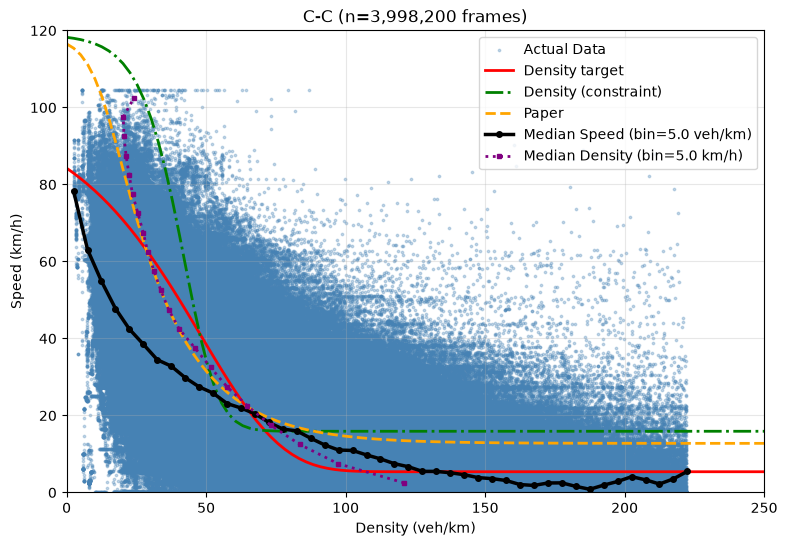

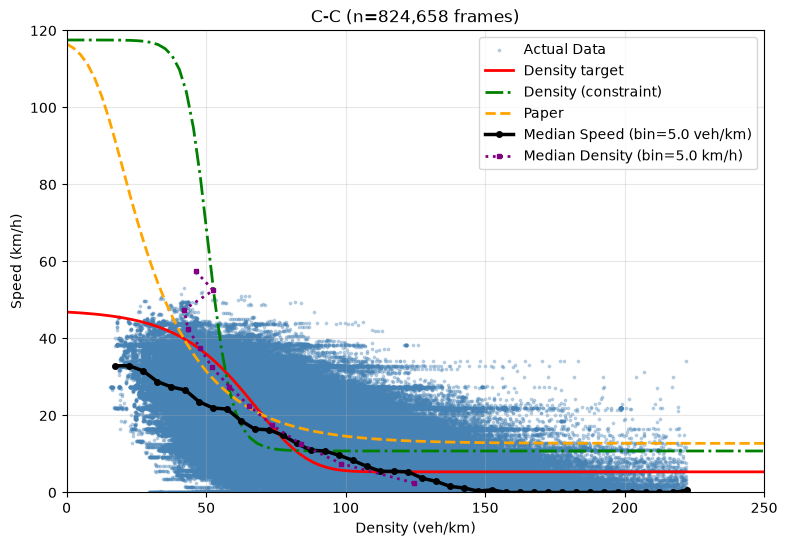

In [38]:
#density target結果と、制約入り結果
results_cc=[0.013, 37.343, 70.589, 29.511, 1.155]
results_cc_paper = [7.93, 73.55, 20.40, 8.0387, 0.2309]  # 論文値 mph 
results_cc_paper_km = [12.762, 118.367, 12.676, 4.995, 0.2309] #論文値
results_cc_all = [0.393, 76.986, 5.050, 29.048, 0.607] #ALLでの推定結果

results_ct=[6.63, 67.87, 22.73, 3.4839, 0.2673]
results_ct_paper = [1.667, 69.799, 17.734, 28.765, 0.694]  # 推定値2（論文値など）

results_cc_density_fit = [10.906, 129.800, 49.964, 4.130, 0.925]
results_density_cc_c=[10.783, 117.533, 49.927, 3.960, 0.858]

results_cc_density_all=[5.391,99.769,149.942,28.178,36.864]
results_cc_density=[5.362,47.486,99.869,16.198,7.072]

results_density_cc_all_c=[15.905,118.984,49.997,8.593,2.475]
#allの制約
# --- mode_id=1 密度ターゲットでの推定結果 ---
# ub=15.905 km/h, uf=118.984 km/h, rhoc=49.997 veh/km, theta1=8.593, theta2=2.475
# テスト密度 MAE: 20.449 veh/km
# テスト速度 MAE: 15.854 km/h_
# --- mode_id=1 密度ターゲットでの推定結果 ---
# ub=10.783 km/h, uf=117.533 km/h, rhoc=49.927 veh/km, theta1=3.960, theta2=0.858
# テスト密度 MAE: 20.400 veh/km
# テスト速度 MAE: 13.954 km/h

#全データと確認
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

#plot_model_logistic(df_all, 1, results_cc_all,results_cc_paper_km,"C-C","Estimated Model(ALL)","Estimated Model in Papaer")

plot_model_logistic_3params(df_all, 1, results_cc_density_all,results_cc_paper_km,results_density_cc_all_c,"C-C","Density target","Paper","Density (constraint)")

plot_model_logistic_3params(df_fd, 1, results_cc_density,results_cc_paper_km,results_density_cc_c,"C-C","Density target","Paper","Density (constraint)")

spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


c:\Users\AMhetero\.conda\envs\GTA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


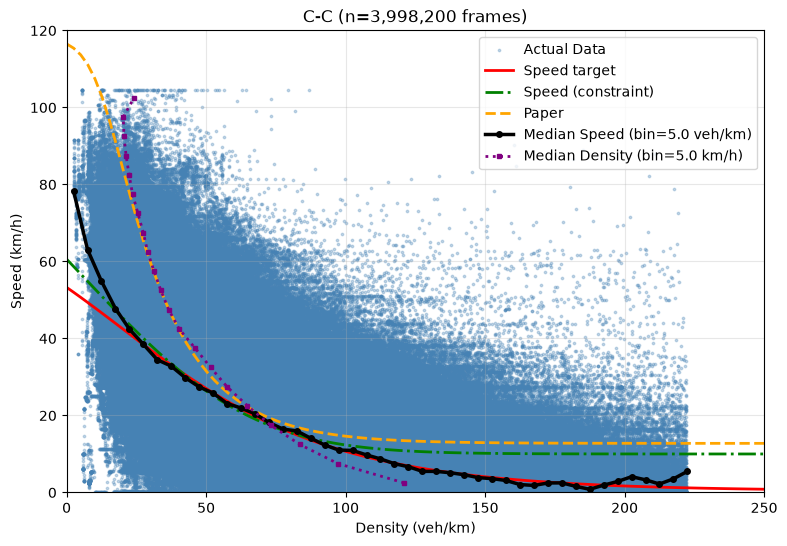

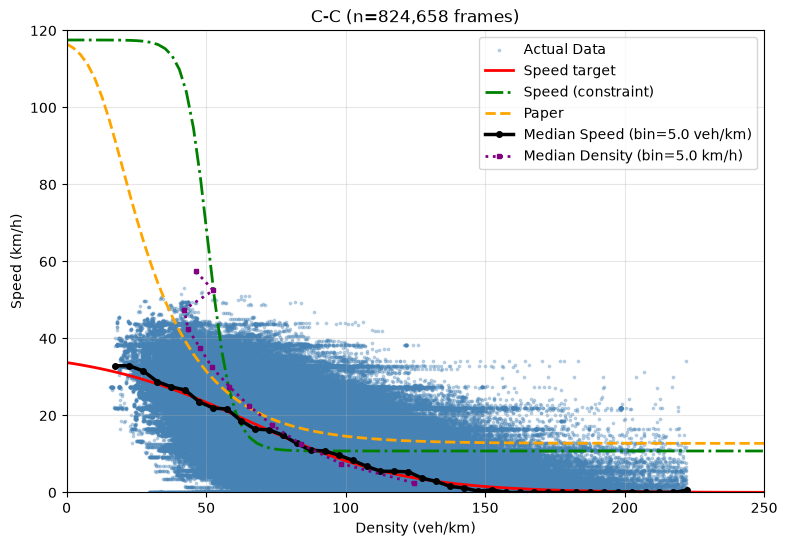

In [39]:
#speed target結果と、制約入り結果
results_cc=[0.013, 37.343, 70.589, 29.511, 1.155]
results_cc_paper = [7.93, 73.55, 20.40, 8.0387, 0.2309]  # 論文値 mph 
results_cc_paper_km = [12.762, 118.367, 12.676, 4.995, 0.2309] #論文値
results_cc_all = [0.393, 76.986, 5.050, 29.048, 0.607] #ALLでの推定結果

results_cc_speed_all_c=[10.005,117.627,48.510,43.705,2.649]
results_cc_speed_c=[10.783,117.533,49.927,3.960,0.858]


results_ct=[6.63, 67.87, 22.73, 3.4839, 0.2673]
results_ct_paper = [1.667, 69.799, 17.734, 28.765, 0.694]  # 推定値2（論文値など）

results_cc_density_fit = [10.906, 129.800, 49.964, 4.130, 0.925]
results_density_cc_c=[10.783, 117.533, 49.927, 3.960, 0.858]

results_cc_density_all=[5.391,99.769,149.942,28.178,36.864]
results_cc_density=[5.362,47.486,99.869,16.198,7.072]

results_density_cc_all_c=[15.905,118.984,49.997,8.593,2.475]
#allの制約
# --- mode_id=1 密度ターゲットでの推定結果 ---
# ub=15.905 km/h, uf=118.984 km/h, rhoc=49.997 veh/km, theta1=8.593, theta2=2.475
# テスト密度 MAE: 20.449 veh/km
# テスト速度 MAE: 15.854 km/h_
# --- mode_id=1 密度ターゲットでの推定結果 ---
# ub=10.783 km/h, uf=117.533 km/h, rhoc=49.927 veh/km, theta1=3.960, theta2=0.858
# テスト密度 MAE: 20.400 veh/km
# テスト速度 MAE: 13.954 km/h

#全データと確認
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

#plot_model_logistic(df_all, 1, results_cc_all,results_cc_paper_km,"C-C","Estimated Model(ALL)","Estimated Model in Papaer")

plot_model_logistic_3params(df_all, 1, results_cc_all,results_cc_paper_km,results_cc_speed_all_c,"C-C","Speed target","Paper","Speed (constraint)")

plot_model_logistic_3params(df_fd, 1, results_cc,results_cc_paper_km,results_cc_speed_c,"C-C","Speed target","Paper","Speed (constraint)")

spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


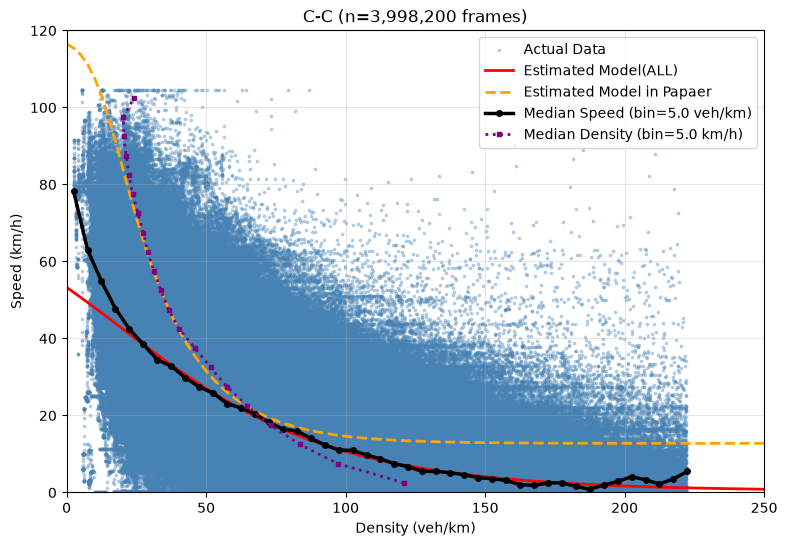

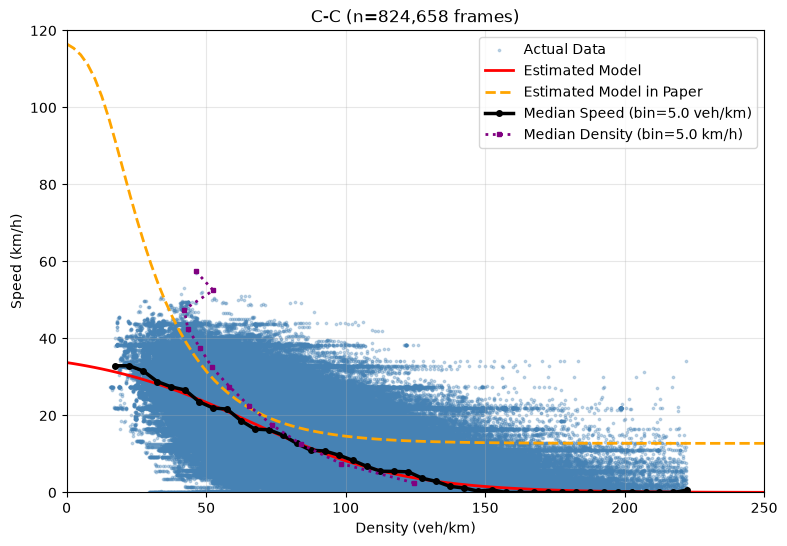

In [169]:
#speed targetでの推定結果
# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=1 推定結果 ---
# ub=0.013 km/h, uf=37.343 km/h, rhoc=70.589 veh/km, theta1=29.511, theta2=1.155
# テストMAE: 5.282 km/h

# ALLでの推定結果
# spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
# --- mode_id=1 推定結果 ---
# ub=0.393 km/h, uf=76.986 km/h, rhoc=5.050 veh/km, theta1=29.048, theta2=0.607
# テストMAE: 7.545 km/h

results_cc=[0.013, 37.343, 70.589, 29.511, 1.155]
results_cc_paper = [7.93, 73.55, 20.40, 8.0387, 0.2309]  # 論文値 mph 
results_cc_paper_km = [12.762, 118.367, 12.676, 4.995, 0.2309] #論文値
results_cc_all = [0.393, 76.986, 5.050, 29.048, 0.607] #ALLでの推定結果

results_ct=[6.63, 67.87, 22.73, 3.4839, 0.2673]
results_ct_paper = [1.667, 69.799, 17.734, 28.765, 0.694]  # 推定値2（論文値など）
# 推定結果を使って実行
#plot_model(df_fd, 1, results_cc,results_cc_paper_km, "C-C")

#無理やり上下を指定
#  spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=1 推定結果 ---
# ub=10.001 km/h, uf=110.005 km/h, rhoc=10.006 veh/km, theta1=9.984, theta2=0.528
# テストMAE: 6.349 km/h

# --- mode_id=1 推定結果 ---
# ub=10.001 km/h, uf=113.045 km/h, rhoc=49.296 veh/km, theta1=38.805, theta2=3.012
# テストMAE: 6.183 km/h


#results_cc=[10.001, 110.005, 10.006, 9.984, 0.528]
#results_cc = [10.001, 113.045, 49.296, 38.805, 3.012]

#ロジスティックモデルの逆関数から、速度に対する密度を推定
# --- mode_id=1 密度ターゲットでの推定結果 ---
# ub=10.906 km/h, uf=129.800 km/h, rhoc=49.964 veh/km, theta1=4.130, theta2=0.925
# テスト密度 MAE: 20.326 veh/km
# テスト速度 MAE: 14.899 km/h
results_cc_density_fit = [10.906, 129.800, 49.964, 4.130, 0.925]

#全データと確認
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

plot_model_logistic(df_all, 1, results_cc_all,results_cc_paper_km,"C-C","Estimated Model(ALL)","Estimated Model in Papaer")

plot_model_logistic(df_fd, 1, results_cc,results_cc_paper_km,"C-C","Estimated Model","Estimated Model in Paper")

spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


c:\Users\AMhetero\.conda\envs\GTA\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


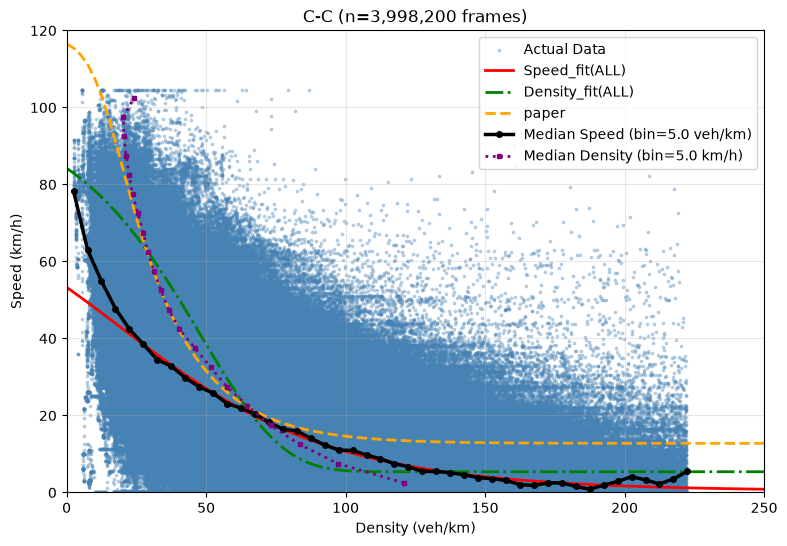

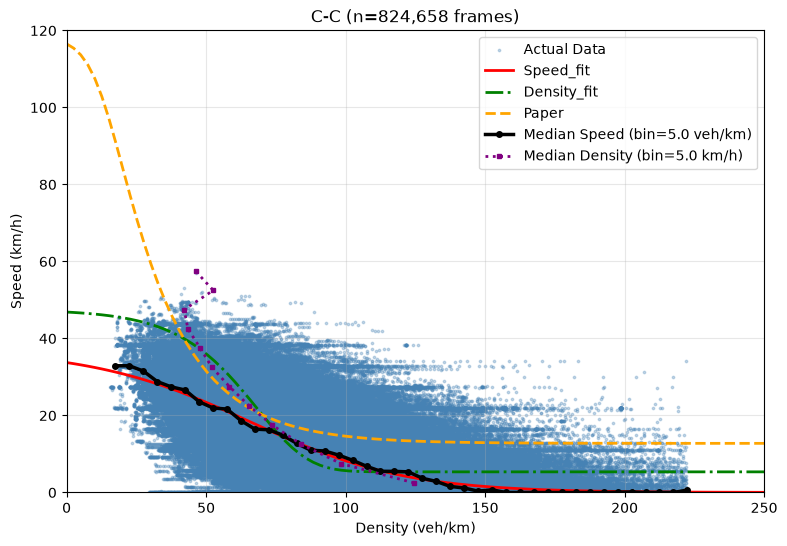

In [35]:
# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=1 推定結果 ---
# ub=0.013 km/h, uf=37.343 km/h, rhoc=70.589 veh/km, theta1=29.511, theta2=1.155
# テストMAE: 5.282 km/h

# ALLでの推定結果
# spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
# --- mode_id=1 推定結果 ---
# ub=0.393 km/h, uf=76.986 km/h, rhoc=5.050 veh/km, theta1=29.048, theta2=0.607
# テストMAE: 7.545 km/h



results_cc=[0.013, 37.343, 70.589, 29.511, 1.155]
results_cc_paper = [7.93, 73.55, 20.40, 8.0387, 0.2309]  # 論文値 mph 
results_cc_paper_km = [12.762, 118.367, 12.676, 4.995, 0.2309] #論文値
results_cc_all = [0.393, 76.986, 5.050, 29.048, 0.607] #ALLでの推定結果

results_ct=[6.63, 67.87, 22.73, 3.4839, 0.2673]
results_ct_paper = [1.667, 69.799, 17.734, 28.765, 0.694]  # 推定値2（論文値など）
# 推定結果を使って実行
#plot_model(df_fd, 1, results_cc,results_cc_paper_km, "C-C")

#無理やり上下を指定
#  spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=1 推定結果 ---
# ub=10.001 km/h, uf=110.005 km/h, rhoc=10.006 veh/km, theta1=9.984, theta2=0.528
# テストMAE: 6.349 km/h

# --- mode_id=1 推定結果 ---
# ub=10.001 km/h, uf=113.045 km/h, rhoc=49.296 veh/km, theta1=38.805, theta2=3.012
# テストMAE: 6.183 km/h


#results_cc=[10.001, 110.005, 10.006, 9.984, 0.528]
#results_cc = [10.001, 113.045, 49.296, 38.805, 3.012]

#ロジスティックモデルの逆関数から、速度に対する密度を推定
# --- mode_id=1 密度ターゲットでの推定結果 ---
# ub=10.906 km/h, uf=129.800 km/h, rhoc=49.964 veh/km, theta1=4.130, theta2=0.925
# テスト密度 MAE: 20.326 veh/km
# テスト速度 MAE: 14.899 km/h
#results_cc_density_fit = [10.906, 129.800, 49.964, 4.130, 0.925]

#制約を減らした場合
# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=1 密度ターゲットでの推定結果 ---
# ub=5.362 km/h, uf=47.486 km/h, rhoc=99.896 veh/km, theta1=16.198, theta2=7.072
# テスト密度 MAE: 18.426 veh/km
# # テスト速度 MAE: 7.177 km/h
results_cc_density_fit = [5.362, 47.486, 99.896, 16.198, 7.072]


# spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
# --- mode_id=1 密度ターゲットでの推定結果 ---
# ub=5.391 km/h, uf=99.769 km/h, rhoc=149.942 veh/km, theta1=28.178, theta2=36.864
# テスト密度 MAE: 18.981 veh/km
# テスト速度 MAE: 10.864 km/h
results_cc_density_fit_all = [5.391, 99.769, 149.942, 28.178, 36.864]



#全データと確認
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

plot_model_logistic_3params(df_all, 1, results_cc_all,results_cc_paper_km,results_cc_density_fit_all, "C-C","Speed_fit(ALL)","paper","Density_fit(ALL)")

plot_model_logistic_3params(df_fd, 1, results_cc,results_cc_paper_km,results_cc_density_fit, "C-C","Speed_fit","Paper","Density_fit")

In [101]:
before = compute_micro_density(filter_invalid_headway(df_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M), ft_to_m=FT_TO_M)
after = df_fd  # duration後(df_final相当)

print("duration前の密度分布:")
print(before[before['mode_id']==1]['mdensity_veh_km'].describe())
print("\nduration後の密度分布:")
print(after[after['mode_id']==1]['mdensity_veh_km'].describe())

spacing <= 4.5m (14.76ft) の行を除外: 2,335,579 -> 2,325,355 (除外 10,224行)
duration前の密度分布:
count    2.119775e+06
mean     7.900612e+01
std      3.268032e+01
min      3.923229e+00
25%      5.535414e+01
50%      7.356143e+01
75%      9.729656e+01
max      2.221286e+02
Name: mdensity_veh_km, dtype: float64

duration後の密度分布:
count    824658.000000
mean         89.779527
std          33.442242
min          15.680542
25%          64.941407
50%          84.557729
75%         109.763797
max         222.128632
Name: mdensity_veh_km, dtype: float64


#### 乗用車クラス　C-T追従

In [41]:
# 実行
# # ① df_finalからミクロ密度を計算(平滑化済み列があればそちらを使う)
# 1. 異常データの除外処理
#df_filtered = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
df_filtered = filter_invalid_headway(df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

# ② 乗用車クラス(C-C追従, mode_id=2)についてロジスティックモデルを推定
# result_cc = fit_nominal_speed_logistic(df_fd, mode_id=2)
# result_cc = fit_nominal_speed_logistic(
#     df_fd, mode_id=2,
#     # lower_bounds=[10.0, 110.0, 10.0, 0.5, 0.05],
#     # upper_bounds=[20.0, 130.0, 50.0, 100.0, 100.0], 
#     # init_params = [15.0, 120.0, 30.0, 10.0, 1.0]
# )

# #全データと確認
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

result_all = fit_nominal_speed_logistic(df_all, mode_id=2)

spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
--- mode_id=2 推定結果 ---
ub=14.793 km/h, uf=111.884 km/h, rhoc=22.340 veh/km, theta1=12.776, theta2=2.257
テストMAE: 9.202 km/h


In [43]:

# 実行例
df_filtered = filter_invalid_headway(
    df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
)
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)


result_all = fit_nominal_density_logistic(df_fd, mode_id=2)

#result_all = fit_nominal_density_logistic(df_all, mode_id=2)

# result_cc_density_fit = fit_nominal_density_logistic(
#     df_fd,
#     mode_id=1,
#     lower_bounds=[10.0, 110.0, 10.0, 0.5, 0.05],
#     upper_bounds=[20.0, 130.0, 50.0, 100.0, 100.0],
#     init_params=[15.0, 120.0, 30.0, 10.0, 1.0],
# )

# # 全車線データで推定してみる 制約は特になし
# df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# # ミクロ密度
# df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

# result_all = fit_nominal_density_logistic(df_all, mode_id=1)


spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
--- mode_id=2 密度ターゲットでの推定結果 ---
ub=2.181 km/h, uf=72.075 km/h, rhoc=50.061 veh/km, theta1=4.324, theta2=23.525
テスト密度 MAE: 11.372 veh/km
テスト速度 MAE: 16.855 km/h


c:\Users\AMhetero\Documents\研究室\Game_Theory_Algorithm\src\nominal_speed_func.py:233: RuntimeWarning: overflow encountered in power
  return ub + (uf - ub) / (1 + exp_term) ** theta2


spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


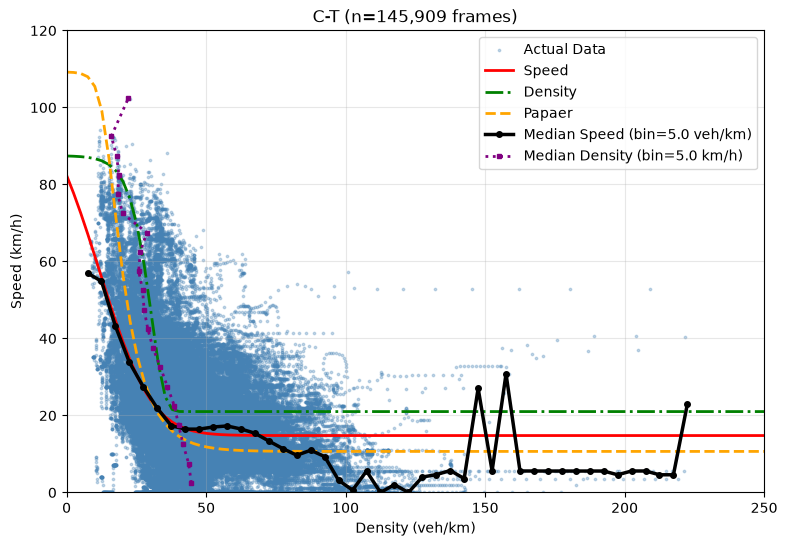

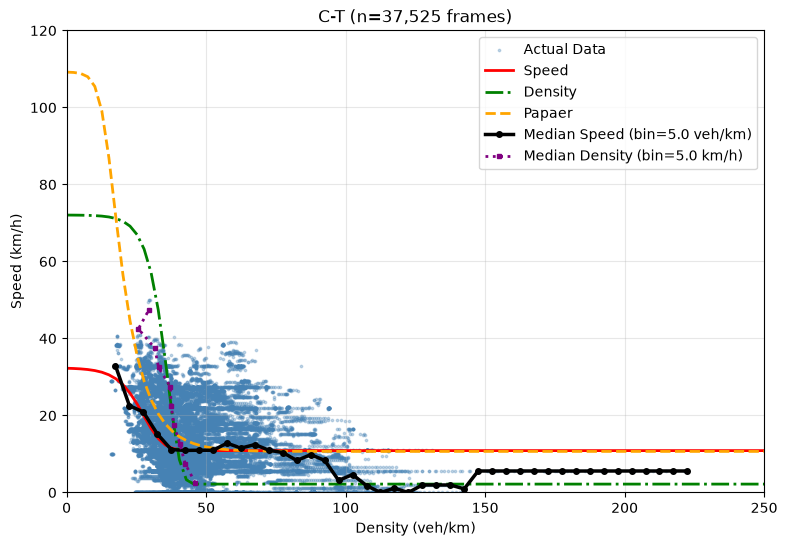

In [ ]:
#プロット
results_ct_speed=[10.880, 32.374, 32.792, 5.142, 2.756] #手元の推定結果

results_ct_speed_all=[14.793, 111.884, 22.340,12.776,2.257] #手元の推定結果
results_ct_paper = [6.63, 67.87, 22.73, 3.4839, 0.2673]  # 論文値 mph 
results_ct_paper_km = [10.670, 109.227, 14.124, 2.165, 0.2673] #論文値 km/h
results_ct_all = [0.393, 76.986, 5.050, 29.048, 0.607] #ALLでの推定結果


#speed all
# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
# --- mode_id=2 推定結果 ---
# ub=14.793 km/h, uf=111.884 km/h, rhoc=22.340 veh/km, theta1=12.776, theta2=2.257
# テストMAE: 9.202 km/h

# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=2 推定結果 ---
# ub=10.880 km/h, uf=32.374 km/h, rhoc=32.792 veh/km, theta1=5.142, theta2=2.756
# テストMAE: 6.488 km/h


#ロジスティックモデルの逆関数から、速度に対する密度を推定
# --- mode_id=2 密度ターゲットでの推定結果 ---
# ub=2.064 km/h, uf=42.624 km/h, rhoc=53.271 veh/km, theta1=3.674, theta2=48.416
# テスト密度 MAE: 11.344 veh/km
# テスト速度 MAE: 12.540 km/h

results_ct_density=[2.181, 72.075, 50.061, 4.324, 23.525] #手元の推定結果

results_ct_density_all=[21.019, 87.491, 49.978,4.579, 70.894] #手元の推定結果
#density all
# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=2 密度ターゲットでの推定結果 ---
# ub=21.019 km/h, uf=87.491 km/h, rhoc=49.978 veh/km, theta1=4.579, theta2=70.894
# テスト密度 MAE: 11.162 veh/km
# テスト速度 MAE: 15.405 km/h

#density futuu 
# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=2 密度ターゲットでの推定結果 ---
# ub=2.181 km/h, uf=72.075 km/h, rhoc=50.061 veh/km, theta1=4.324, theta2=23.525
# テスト密度 MAE: 11.372 veh/km
# テスト速度 MAE: 16.855 km/h
# c:\Users\AMhetero\Documents\研究室\Game_Theory_Algorithm\src\nominal_speed_func.py:233: RuntimeWarning: overflow encountered in power
#   return ub + (uf - ub) / (1 + exp_term) ** theta2

#データの用意
df_filtered = filter_invalid_headway(
    df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
)
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

#全データと確認
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

plot_model_logistic_3params(df_all, 2, results_ct_speed_all,results_ct_paper_km,results_ct_density_all, "C-T","Speed","Papaer","Density")

plot_model_logistic_3params(df_fd, 2, results_ct_speed,results_ct_paper_km,results_ct_density, "C-T","Speed","Papaer","Density")

### トラッククラス　パラメータ推定

In [19]:
def plot_model_underwood(
    df,
    mode_id,
    params,
    params2,
    params3,
    mode_name,
    label1='Estimated Model(constraint)',
    label2='Estimated Model in paper',
    label3='Estimated Model',
):
    uf, rhoc = params
    uf2, rhoc2= params2
    uf3, rhoc3= params3

    # 1. 指定した mode_id のデータだけに絞り込み（SettingWithCopyWarning防止のため copy）
    df_mode = df[df['mode_id'] == mode_id].copy()

    # 2. speed_kmh 列を df_mode 自体に確実に作成
    if 'speed_kmh' not in df_mode.columns:
        df_mode['speed_kmh'] = df_mode['v_Vel'] * 0.3048 * 3.6

    # 0〜250 veh/km の範囲で100点の密度グリッドを作成
    rho_range = np.linspace(0, 250, 100)

    # 予測速度の計算
    v_pred = underwood_speed_density(rho_range, uf, rhoc)
    v_pred2 = underwood_speed_density(rho_range, uf2, rhoc2)
    v_pred3 = underwood_speed_density(rho_range, uf3, rhoc3)

    # --- ある密度における速度の中央値 ---
    bin_width = 5.0
    max_density = 250
    bins = np.arange(0, max_density + bin_width, bin_width)
    df_mode['density_bin'] = pd.cut(
        df_mode['mdensity_veh_km'], bins=bins, include_lowest=True
    )
    bin_stats = df_mode.groupby('density_bin', observed=True).agg(
        median_speed=('speed_kmh', 'median'), count=('speed_kmh', 'count')
    )
    bin_centers = [interval.mid for interval in bin_stats.index]

    # --- ある速度における密度の中央値 ---
    bin_width_v = 5.0
    max_speed = 120
    bins_v = np.arange(0, max_speed + bin_width_v, bin_width_v)
    df_mode['speed_bin'] = pd.cut(
        df_mode['speed_kmh'], bins=bins_v, include_lowest=True
    )
    bin_stats_v = df_mode.groupby('speed_bin', observed=True).agg(
        median_density=('mdensity_veh_km', 'median')
    )
    bin_centers_v = [interval.mid for interval in bin_stats_v.index]

    # --- 描画処理 ---
    plt.figure(figsize=(9, 6))

    # 実測データ散布図
    plt.scatter(
        df_mode['mdensity_veh_km'],
        df_mode['speed_kmh'],
        s=3,
        alpha=0.3,
        color='steelblue',
        label='Actual Data',
    )

    # 各モデル曲線（引数で受け取った label1, label2, label3 を適用）
    plt.plot(
        rho_range,
        v_pred,
        color='red',
        linewidth=2,
        label=label1,
    )
    plt.plot(
        rho_range,
        v_pred3,
        color='green',
        linewidth=2,
        linestyle='-.',
        label=label3,
    )
    plt.plot(
        rho_range,
        v_pred2,
        color='orange',
        linewidth=2,
        linestyle='--',
        label=label2,
    )

    # 中央値プロット
    plt.plot(
        bin_centers,
        bin_stats['median_speed'],
        color='black',
        linewidth=2.5,
        marker='o',
        markersize=4,
        label=f'Median Speed (bin={bin_width} veh/km)',
    )
    plt.plot(
        bin_stats_v['median_density'],
        bin_centers_v,
        color='purple',
        linewidth=2,
        linestyle=':',
        marker='s',
        markersize=3,
        label=f'Median Density (bin={bin_width_v} km/h)',
    )

    # 軸・タイトルの設定
    plt.xlabel('Density (veh/km)')
    plt.ylabel('Speed (km/h)')
    plt.xlim(0, 250)
    plt.ylim(0, 120)
    plt.title(f'{mode_name} (n={len(df_mode):,} frames)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


In [33]:
def plot_model_underwood_2(
    df,
    mode_id,
    params,
    params2,
    #params3,
    mode_name,
    label1='Estimated Model',
    label2='Estimated Model in paper',
    #label3='Estimated Model',
):
    uf, rhoc = params
    uf2, rhoc2= params2
    #uf3, rhoc3= params3

    # 1. 指定した mode_id のデータだけに絞り込み（SettingWithCopyWarning防止のため copy）
    df_mode = df[df['mode_id'] == mode_id].copy()

    # 2. speed_kmh 列を df_mode 自体に確実に作成
    if 'speed_kmh' not in df_mode.columns:
        df_mode['speed_kmh'] = df_mode['v_Vel'] * 0.3048 * 3.6

    # 0〜250 veh/km の範囲で100点の密度グリッドを作成
    rho_range = np.linspace(0, 250, 100)

    # 予測速度の計算
    v_pred = underwood_speed_density(rho_range, uf, rhoc)
    v_pred2 = underwood_speed_density(rho_range, uf2, rhoc2)
    #v_pred3 = underwood_speed_density(rho_range, uf3, rhoc3)

    # --- ある密度における速度の中央値 ---
    bin_width = 5.0
    max_density = 250
    bins = np.arange(0, max_density + bin_width, bin_width)
    df_mode['density_bin'] = pd.cut(
        df_mode['mdensity_veh_km'], bins=bins, include_lowest=True
    )
    bin_stats = df_mode.groupby('density_bin', observed=True).agg(
        median_speed=('speed_kmh', 'median'), count=('speed_kmh', 'count')
    )
    bin_centers = [interval.mid for interval in bin_stats.index]

    # --- ある速度における密度の中央値 ---
    bin_width_v = 5.0
    max_speed = 120
    bins_v = np.arange(0, max_speed + bin_width_v, bin_width_v)
    df_mode['speed_bin'] = pd.cut(
        df_mode['speed_kmh'], bins=bins_v, include_lowest=True
    )
    bin_stats_v = df_mode.groupby('speed_bin', observed=True).agg(
        median_density=('mdensity_veh_km', 'median')
    )
    bin_centers_v = [interval.mid for interval in bin_stats_v.index]

    # --- 描画処理 ---
    plt.figure(figsize=(9, 6))

    # 実測データ散布図
    plt.scatter(
        df_mode['mdensity_veh_km'],
        df_mode['speed_kmh'],
        s=3,
        alpha=0.3,
        color='steelblue',
        label='Actual Data',
    )

    # 各モデル曲線（引数で受け取った label1, label2, label3 を適用）
    plt.plot(
        rho_range,
        v_pred,
        color='red',
        linewidth=2,
        label=label1,
    )
    # plt.plot(
    #     rho_range,
    #     v_pred3,
    #     color='green',
    #     linewidth=2,
    #     linestyle='-.',
    #     label=label3,
    # )
    plt.plot(
        rho_range,
        v_pred2,
        color='orange',
        linewidth=2,
        linestyle='--',
        label=label2,
    )

    # 中央値プロット
    plt.plot(
        bin_centers,
        bin_stats['median_speed'],
        color='black',
        linewidth=2.5,
        marker='o',
        markersize=4,
        label=f'Median Speed (bin={bin_width} veh/km)',
    )
    plt.plot(
        bin_stats_v['median_density'],
        bin_centers_v,
        color='purple',
        linewidth=2,
        linestyle=':',
        marker='s',
        markersize=3,
        label=f'Median Density (bin={bin_width_v} km/h)',
    )

    # 軸・タイトルの設定
    plt.xlabel('Density (veh/km)')
    plt.ylabel('Speed (km/h)')
    plt.xlim(0, 250)
    plt.ylim(0, 120)
    plt.title(f'{mode_name} (n={len(df_mode):,} frames)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


#### T-T追従

In [8]:
def underwood_speed_density(rho, uf, rhoc):
    """
    論文Eq(18)のアンダーウッド速度-密度モデル。
    g(rho) = uf * exp(-rho / rhoc)
    """
    return uf * np.exp(np.clip(-rho / rhoc, -100, 100))  # オーバーフロー防止


def fit_nominal_speed_underwood(df, mode_id, density_col='mdensity_veh_km', speed_col='v_Vel',
                                  lower_bounds=None, upper_bounds=None, init_params=None,
                                  max_eval=15000, test_size=0.3, random_state=42):
    """
    論文Algorithm 1 Step 1(a): 指定した追従タイプ(mode_id)のデータから、
    アンダーウッドモデルのパラメータ(uf, rhoc)を
    ISRES(改良型確率的ランキング進化戦略)で推定する。トラッククラス用。

    パラメータの並び順: [uf, rhoc]
    - uf: 自由流速度(km/h)      - rhoc: 臨界密度(veh/km)

    lower_bounds/upper_bounds/init_paramsを渡せば探索範囲・初期値を制約できる。
    """
    # ① 対象の追従タイプ(mode_id)に絞り、欠損を除く
    data = df[df['mode_id'] == mode_id].dropna(subset=[density_col, speed_col]).copy()
    if len(data) == 0:
        raise ValueError(f"mode_id={mode_id} に該当するデータがありません。")

    # ② 速度をft/s -> km/hに変換(密度は既にveh/km前提)
    data['speed_kmh'] = data[speed_col] * 0.3048 * 3.6

    X = data[density_col].values   # 密度(veh/km)
    Y = data['speed_kmh'].values   # 速度(km/h)

    # ③ 70:30で学習・評価データに分割(論文と同じ比率)
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    # ④ 目的関数：学習データに対するL1誤差の合計(論文のl(theta)の定義通り) gradは今回は使用しない
    def objective(x, grad):
        uf, rhoc = x
        pred = underwood_speed_density(X_train, uf, rhoc)
        return np.sum(np.abs(Y_train - pred))

    # ⑤ 探索範囲・初期値のデフォルト(論文Table4の実測値を参考に設定。指定があれば上書き)
    #    論文の値(km換算): T-T → uf≈68.5, rhoc≈25.9 / T-C → uf≈96.7, rhoc≈49.4
    if lower_bounds is None:
        lower_bounds = [20.0, 5.0]        # [uf, rhoc]
    if upper_bounds is None:
        upper_bounds = [150.0, 200.0]
    if init_params is None:
        init_params = [80.0, 40.0]

    # ⑥ ISRES(GN_ISRES)で最適化
    opt = nlopt.opt(nlopt.GN_ISRES, 2)
    opt.set_lower_bounds(lower_bounds)
    opt.set_upper_bounds(upper_bounds)
    opt.set_min_objective(objective)
    opt.set_maxeval(max_eval)
    best_params = opt.optimize(init_params)

    # ⑦ テストデータでMAEを評価
    uf, rhoc = best_params
    Y_pred_test = underwood_speed_density(X_test, uf, rhoc)
    test_mae = mean_absolute_error(Y_test, Y_pred_test)

    print(f"--- mode_id={mode_id} 推定結果(アンダーウッド) ---")
    print(f"uf={uf:.3f} km/h, rhoc={rhoc:.3f} veh/km")
    print(f"テストMAE: {test_mae:.3f} km/h")

    return {'mode_id': mode_id, 'uf': uf, 'rhoc': rhoc, 'test_mae': test_mae}

#データの用意
df_filtered = filter_invalid_headway(
    df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
)
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

# 実行：トラッククラス(T-T追従, mode_id=4)についてアンダーウッドモデルを推定
result_tt = fit_nominal_speed_underwood(df_fd, mode_id=4)

#全データと確認
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

result_tt = fit_nominal_speed_underwood(df_all, mode_id=4)

spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
--- mode_id=4 推定結果(アンダーウッド) ---
uf=20.000 km/h, rhoc=112.144 veh/km
テストMAE: 5.623 km/h
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
--- mode_id=4 推定結果(アンダーウッド) ---
uf=30.575 km/h, rhoc=76.068 veh/km
テストMAE: 7.195 km/h


In [24]:
#制約を追加
#データの用意
df_filtered = filter_invalid_headway(
    df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
)
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

# 実行：トラッククラス(T-T追従, mode_id=4)についてアンダーウッドモデルを推定
result_tt = fit_nominal_speed_underwood(df_fd, mode_id=4,
                                        lower_bounds = [63.0, 20.0],
                                        upper_bounds = [73.0, 30.0],
                                        init_params = [68.0, 25.0])

#全データと確認
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

result_tt = fit_nominal_speed_underwood(df_all, mode_id=4,
                                        lower_bounds = [63.0, 20.0],
                                        upper_bounds = [73.0, 30.0],
                                        init_params = [68.0, 25.0])

spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
--- mode_id=4 推定結果(アンダーウッド) ---
uf=63.000 km/h, rhoc=20.000 veh/km
テストMAE: 5.830 km/h
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
--- mode_id=4 推定結果(アンダーウッド) ---
uf=63.000 km/h, rhoc=22.892 veh/km
テストMAE: 8.022 km/h


spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


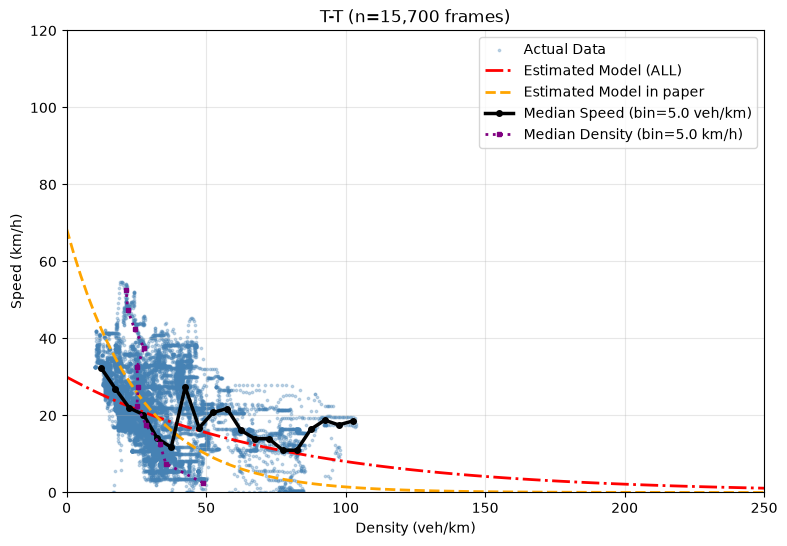

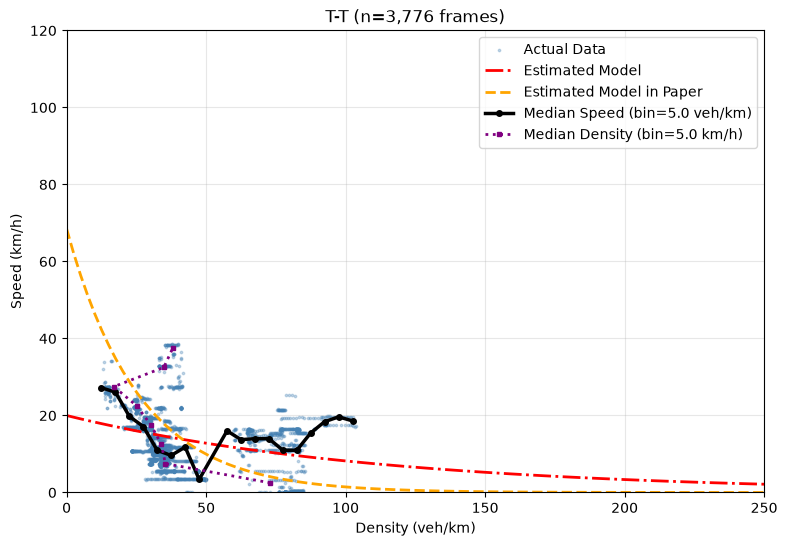

In [15]:
#プロット
# --- mode_id=4 推定結果(アンダーウッド) ---
# uf=20.000 km/h, rhoc=112.144 veh/km
# テストMAE: 5.623 km/h
results_tt=[20.000, 112.144] #手元の推定結果

results_tt_paper = [42.55,41.74]  # 論文値 mph 
results_tt_paper_km = [68.478, 25.936] #論文値 km/h

# spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
# --- mode_id=4 推定結果(アンダーウッド) ---
# uf=30.575 km/h, rhoc=76.068 veh/km
# テストMAE: 7.195 km/h
results_tt_all = [30.000, 76.068] #ALLでの推定結果

# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=2 推定結果 ---
# ub=10.880 km/h, uf=32.374 km/h, rhoc=32.792 veh/km, theta1=5.142, theta2=2.756
# テストMAE: 6.488 km/h


#ロジスティックモデルの逆関数から、速度に対する密度を推定
# --- mode_id=2 密度ターゲットでの推定結果 ---
# ub=2.064 km/h, uf=42.624 km/h, rhoc=53.271 veh/km, theta1=3.674, theta2=48.416
# テスト密度 MAE: 11.344 veh/km
# テスト速度 MAE: 12.540 km/h

results_tt_density=[20.000, 112.144]#手元の推定結果


#データの用意
df_filtered = filter_invalid_headway(
    df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
)
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

#全データと確認

df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

plot_model_underwood(df_all, 4, results_tt_paper_km,results_tt_all, "T-T")

plot_model_underwood(df_fd, 4, results_tt_paper_km,results_tt, "T-T","Estimated Model in Paper","Estimated Model")

spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


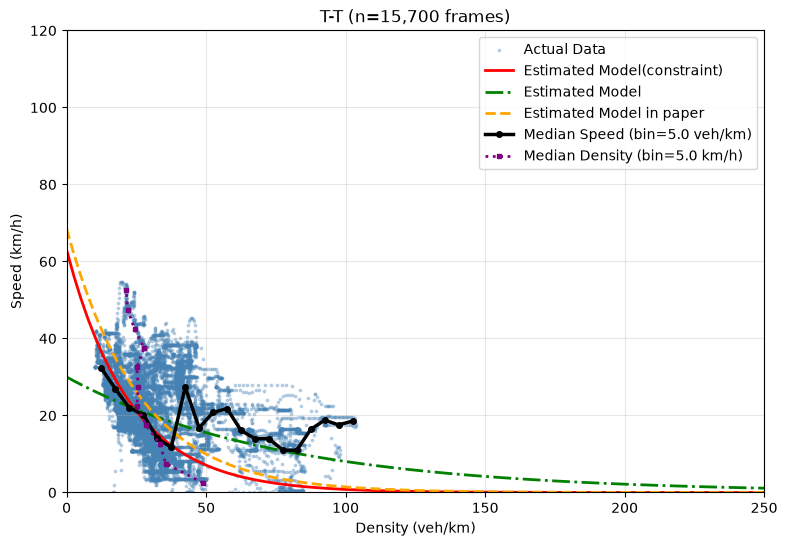

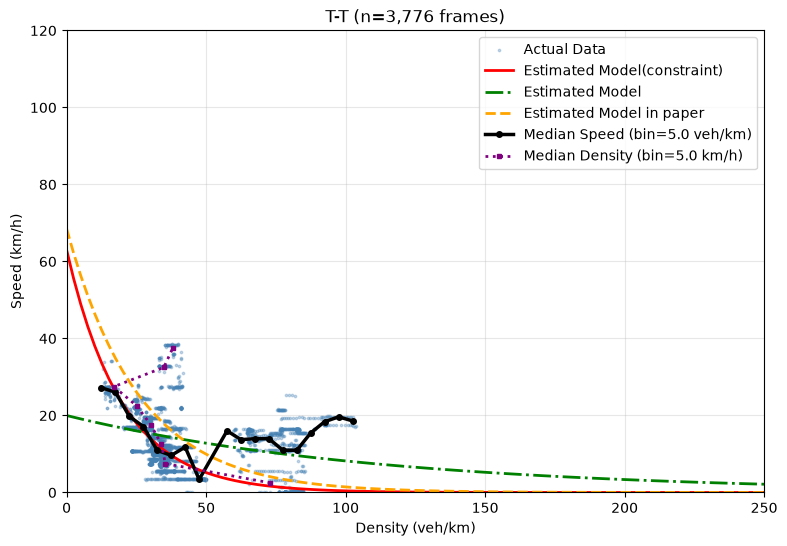

In [25]:
#プロット
# --- mode_id=4 推定結果(アンダーウッド) ---
# uf=20.000 km/h, rhoc=112.144 veh/km
# テストMAE: 5.623 km/h
results_tt=[20.000, 112.144] #手元の推定結果

results_tt_paper = [42.55,41.74]  # 論文値 mph 
results_tt_paper_km = [68.478, 25.936] #論文値 km/h

# spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
# --- mode_id=4 推定結果(アンダーウッド) ---
# uf=30.575 km/h, rhoc=76.068 veh/km
# テストMAE: 7.195 km/h
results_tt_all = [30.000, 76.068] #ALLでの推定結果

# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=2 推定結果 ---
# ub=10.880 km/h, uf=32.374 km/h, rhoc=32.792 veh/km, theta1=5.142, theta2=2.756
# テストMAE: 6.488 km/h

results_tt_all_const = [63.000,22.892]
results_tt_const = [63.000, 20.000]

#ロジスティックモデルの逆関数から、速度に対する密度を推定
# --- mode_id=2 密度ターゲットでの推定結果 ---
# ub=2.064 km/h, uf=42.624 km/h, rhoc=53.271 veh/km, theta1=3.674, theta2=48.416
# テスト密度 MAE: 11.344 veh/km
# テスト速度 MAE: 12.540 km/h

#seiyaku 論文のｐm5くらい
# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=4 推定結果(アンダーウッド) ---
# uf=63.000 km/h, rhoc=20.000 veh/km
# テストMAE: 5.830 km/h
# spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
# --- mode_id=4 推定結果(アンダーウッド) ---
# uf=63.000 km/h, rhoc=22.892 veh/km
# テストMAE: 8.022 km/h


results_tt_density=[20.000, 112.144]#手元の推定結果


#データの用意
df_filtered = filter_invalid_headway(
    df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
)
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

#全データと確認

df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

plot_model_underwood(df_all, 4, results_tt_all_const,results_tt_paper_km,results_tt_all, "T-T")

plot_model_underwood(df_fd, 4, results_tt_const,results_tt_paper_km,results_tt, "T-T")

#### T-C追従

In [149]:
#データの用意
df_filtered = filter_invalid_headway(
    df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
)
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

# 実行：トラッククラス(T-T追従, mode_id=4)についてアンダーウッドモデルを推定
result_tc = fit_nominal_speed_underwood(df_fd, mode_id=3)

#全データと確認
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

result_tc_all = fit_nominal_speed_underwood(df_all, mode_id=3)

spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
--- mode_id=3 推定結果(アンダーウッド) ---
uf=31.850 km/h, rhoc=64.968 veh/km
テストMAE: 5.396 km/h
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
--- mode_id=3 推定結果(アンダーウッド) ---
uf=41.376 km/h, rhoc=66.958 veh/km
テストMAE: 8.372 km/h


spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


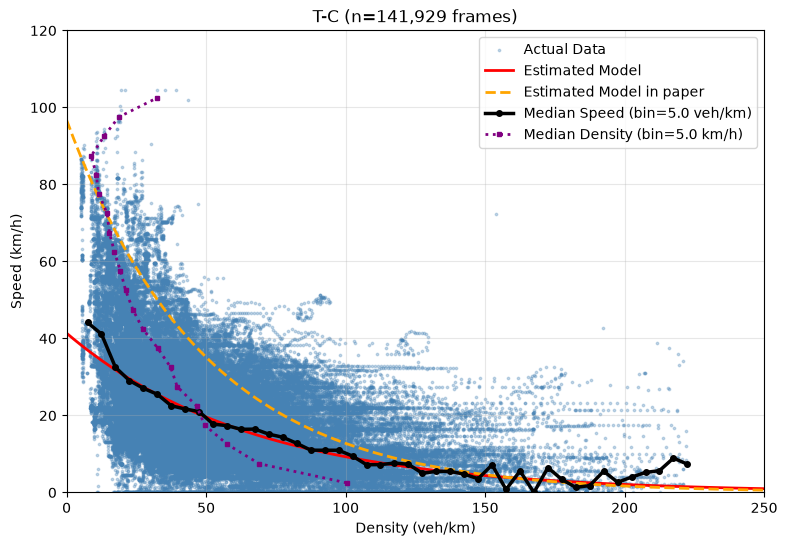

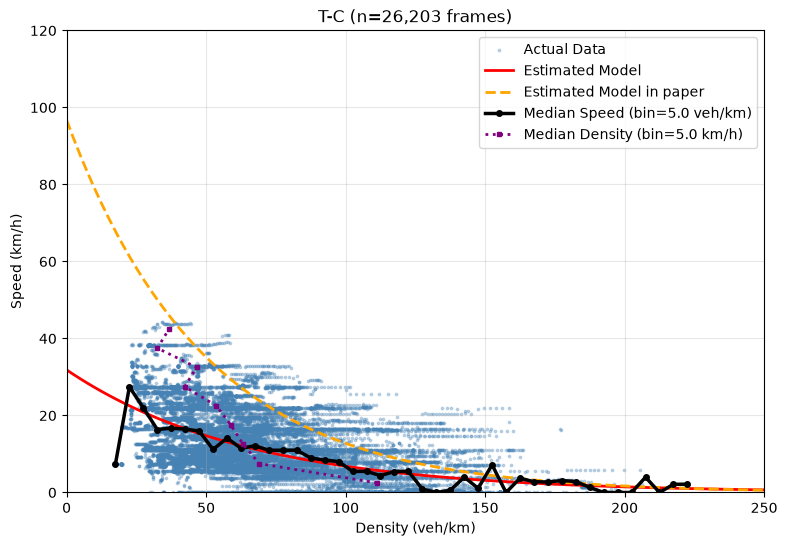

(None,)

In [ ]:
#プロット
# --- mode_id=3 推定結果(アンダーウッド) ---
# uf=31.850 km/h, rhoc=64.968 veh/km
# テストMAE: 5.396 km/h
results_tc=[31.850, 64.968] #手元の推定結果

results_tc_paper = [60.10,79.49]  # 論文値 mph 
results_tc_paper_km = [96.722, 49.393] #論文値 km/h

# spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
# --- mode_id=3 推定結果(アンダーウッド) ---
# uf=41.376 km/h, rhoc=66.958 veh/km
# テストMAE: 8.372 km/h
results_tc_all = [41.376, 66.958] #ALLでの推定結果

# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=2 推定結果 ---
# ub=10.880 km/h, uf=32.374 km/h, rhoc=32.792 veh/km, theta1=5.142, theta2=2.756
# テストMAE: 6.488 km/h


#ロジスティックモデルの逆関数から、速度に対する密度を推定
# --- mode_id=2 密度ターゲットでの推定結果 ---
# ub=2.064 km/h, uf=42.624 km/h, rhoc=53.271 veh/km, theta1=3.674, theta2=48.416
# テスト密度 MAE: 11.344 veh/km
# テスト速度 MAE: 12.540 km/h

results_tc_density=[31.850, 64.968]#手元の推定結果


#データの用意
df_filtered = filter_invalid_headway(
    df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
)
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

#全データと確認

df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

plot_model_underwood_2(df_all, 3, results_tc_all,results_tc_paper_km, "T-C","Estimated Model")

plot_model_underwood_2(df_fd, 3, results_tc,results_tc_paper_km ,"T-C","Estimated Model"),

In [23]:
#制約を追加
#データの用意
df_filtered = filter_invalid_headway(
    df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
)
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

# 実行：トラッククラス(T-T追従, mode_id=4)についてアンダーウッドモデルを推定
result_tt = fit_nominal_speed_underwood(df_fd, mode_id=3,
                                        lower_bounds = [90.0, 45.0],
                                        upper_bounds = [100.0, 55.0],
                                        init_params = [95.0, 50.0])

#全データと確認
df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

result_tt = fit_nominal_speed_underwood(df_all, mode_id=3,
                                        lower_bounds = [90.0, 45.0],
                                        upper_bounds = [100.0, 55.0],
                                        init_params = [95.0, 50.0])

spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
--- mode_id=3 推定結果(アンダーウッド) ---
uf=90.000 km/h, rhoc=45.000 veh/km
テストMAE: 11.269 km/h
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
--- mode_id=3 推定結果(アンダーウッド) ---
uf=90.000 km/h, rhoc=45.000 veh/km
テストMAE: 13.890 km/h


spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)


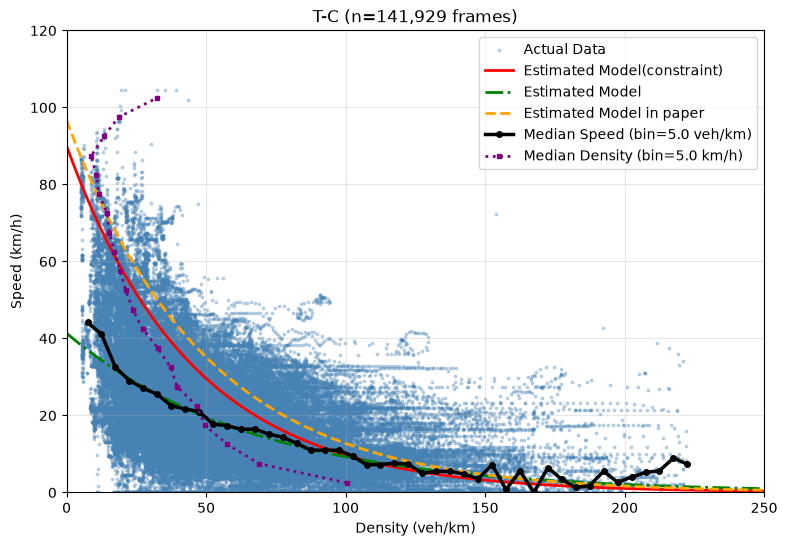

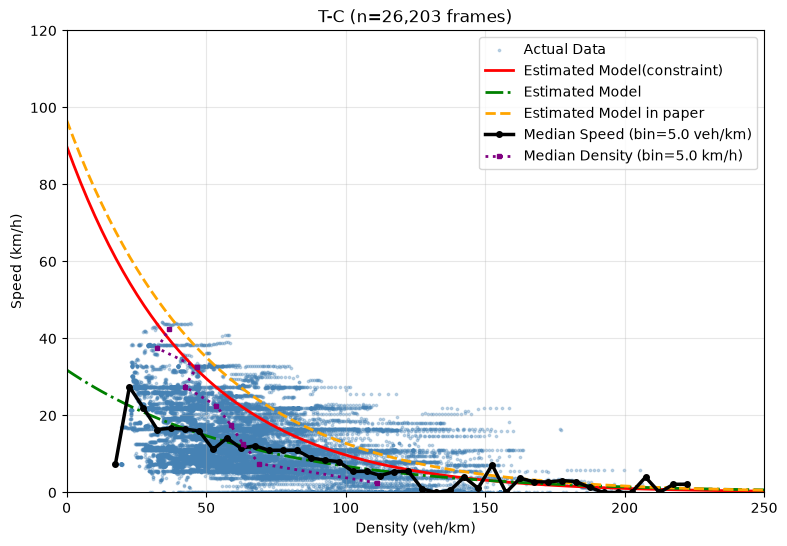

In [26]:
#プロット 制約を追加
# --- mode_id=3 推定結果(アンダーウッド) ---
# uf=31.850 km/h, rhoc=64.968 veh/km
# テストMAE: 5.396 km/h
results_tc=[31.850, 64.968] #手元の推定結果

results_tc_paper = [60.10,79.49]  # 論文値 mph 
results_tc_paper_km = [96.722, 49.393] #論文値 km/h

# spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
# --- mode_id=3 推定結果(アンダーウッド) ---
# uf=41.376 km/h, rhoc=66.958 veh/km
# テストMAE: 8.372 km/h
results_tc_all = [41.376, 66.958] #ALLでの推定結果

# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=2 推定結果 ---
# ub=10.880 km/h, uf=32.374 km/h, rhoc=32.792 veh/km, theta1=5.142, theta2=2.756
# テストMAE: 6.488 km/h


#ロジスティックモデルの逆関数から、速度に対する密度を推定
# --- mode_id=2 密度ターゲットでの推定結果 ---
# ub=2.064 km/h, uf=42.624 km/h, rhoc=53.271 veh/km, theta1=3.674, theta2=48.416
# テスト密度 MAE: 11.344 veh/km
# テスト速度 MAE: 12.540 km/h

results_tc_all_const=[90.000,45.000]

results_tc_const=[90.000,45.000]
# #seiyaku
# spacing <= 4.5m (14.76ft) の行を除外: 895,533 -> 892,162 (除外 3,371行)
# --- mode_id=3 推定結果(アンダーウッド) ---
# uf=90.000 km/h, rhoc=45.000 veh/km
# テストMAE: 11.269 km/h
# spacing <= 4.5m (14.76ft) の行を除外: 4,566,387 -> 4,333,759 (除外 232,628行)
# --- mode_id=3 推定結果(アンダーウッド) ---
# uf=90.000 km/h, rhoc=45.000 veh/km
# テストMAE: 13.890 km/h

results_tc_density=[31.850, 64.968]#手元の推定結果


#データの用意
df_filtered = filter_invalid_headway(
    df_final, min_spacing_m=4.5, ft_to_m=FT_TO_M
)
df_fd = compute_micro_density(df_filtered, ft_to_m=FT_TO_M)

#全データと確認

df_all = filter_invalid_headway(df_with_mode, min_spacing_m=4.5, ft_to_m=FT_TO_M)
# ミクロ密度
df_all = compute_micro_density(df_all, ft_to_m=FT_TO_M)

plot_model_underwood(df_all, 3, results_tc_all_const,results_tc_paper_km,results_tc_all, "T-C")

plot_model_underwood(df_fd, 3, results_tc_const,results_tc_paper_km,results_tc, "T-C")

## スケーリングパラメータの推定

### C-T 用

In [153]:
def fit_scaling_parameter_logistic(df, mode_id, nominal_params,
                                     density_col='mdensity_veh_km', speed_col='v_Vel',
                                     lower_bound=0.1, upper_bound=5.0, init_param=1.0,
                                     max_eval=15000, test_size=0.3, random_state=42):
    """
    論文Algorithm 1 Step 1(b): 推定済みの名目速度関数f(=f11)を基準に、
    スケーリングパラメータ a2 を ISRES で推定する。
    論文Eq(20): f12(rho) = f(rho / a2)

    nominal_params: Step 1(a)で推定したロジスティックのパラメータ
                    (fit_nominal_speed_logistic の戻り値をそのまま渡す)
    lower_bound/upper_bound/init_param: スケーリングパラメータの探索範囲・初期値
    """
    # ① 対象の追従タイプ(mode_id)に絞り、欠損を除く
    data = df[df['mode_id'] == mode_id].dropna(subset=[density_col, speed_col]).copy()
    if len(data) == 0:
        raise ValueError(f"mode_id={mode_id} に該当するデータがありません。")

    # ② 速度をft/s -> km/hに変換(密度は既にveh/km前提)
    data['speed_kmh'] = data[speed_col] * 0.3048 * 3.6

    X = data[density_col].values   # 密度(veh/km)
    Y = data['speed_kmh'].values   # 速度(km/h)

    # ③ 70:30で学習・評価データに分割(論文と同じ比率)
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    # ④ 名目速度関数のパラメータを取り出す(これらは固定。推定するのはスケーリングのみ)
    ub, uf = nominal_params['ub'], nominal_params['uf']
    rhoc = nominal_params['rhoc']
    theta1, theta2 = nominal_params['theta1'], nominal_params['theta2']

    # ⑤ 目的関数：密度を a で割ってから名目速度関数に入れ、L1誤差の合計を取る(Eq(20))
    def objective(x, grad):
        a = x[0]
        pred = logistic_speed_density(X_train / a, ub, uf, rhoc, theta1, theta2)
        return np.sum(np.abs(Y_train - pred))

    # ⑥ ISRES(GN_ISRES)で最適化(推定するのはスケーリングパラメータ1つだけ)
    #    論文Table5の実測値: a2 = 0.4528
    opt = nlopt.opt(nlopt.GN_ISRES, 1)
    opt.set_lower_bounds([lower_bound])
    opt.set_upper_bounds([upper_bound])
    opt.set_min_objective(objective)
    opt.set_maxeval(max_eval)
    best_param = opt.optimize([init_param])

    # ⑦ テストデータでMAEを評価
    a = best_param[0]
    Y_pred_test = logistic_speed_density(X_test / a, ub, uf, rhoc, theta1, theta2)
    test_mae = mean_absolute_error(Y_test, Y_pred_test)

    print(f"--- mode_id={mode_id} スケーリングパラメータ推定結果 ---")
    print(f"a = {a:.4f}")
    print(f"テストMAE: {test_mae:.3f} km/h")

    return {'mode_id': mode_id, 'scaling_param': a, 'test_mae': test_mae}


# 実行：C-T追従(mode_id=2)のスケーリングパラメータ a2 を推定
# nominal_paramsには、C-C(mode_id=1)で推定した結果をそのまま渡す
result_a2 = fit_scaling_parameter_logistic(df_fd, mode_id=2, nominal_params=result_cc)

--- mode_id=2 スケーリングパラメータ推定結果 ---
a = 1.0028
テストMAE: 6.488 km/h


### T-C用

### アーカイブ

In [ ]:
#異常な密度を除外するコード
min_spacing_m = 4.5  # これ未満は「明らかにおかしい」として除外する閾値

df_fd = df_final.copy()
df_fd['spacing_m'] = df_fd['Space_Headway_smooth'] * FT_TO_M

before = len(df_fd)
df_fd = df_fd[df_fd['spacing_m'] > min_spacing_m]
after = len(df_fd)
print(f"spacing <= {min_spacing_m}m の行を除外: {before:,} -> {after:,} (除外 {before-after:,}行)")

df_fd['density_veh_km'] = 1000 / df_fd['spacing_m']
df_fd['speed_kmh'] = df_fd['v_Vel'] * FT_TO_M * 3.6
df_fd['flow_veh_h'] = df_fd['density_veh_km'] * df_fd['speed_kmh']

#除外後のペアタイプごとの密度速度分布を図示
pair_types = [1,2, 3, 4]
mode_map = {
    1: 'C-C',
    2: 'C-T',
    3: 'T-C',
    4: 'T-T'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, pt in zip(axes.flat, pair_types):
    sub = df_fd[df_fd['mode_id'] == pt]
    ax.scatter(sub['density_veh_km'], sub['speed_kmh'], s=3, alpha=0.3, color='steelblue')
    ax.set_xlabel('Density (veh/km)')
    ax.set_ylabel('speed(km/h)')
    ax.set_title(f'{mode_map[pt]} (n={len(sub):,} frames)')
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()